# Elist Order Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, PercentFormatter

In [2]:
def format_monthly_axis(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    for year in [2019, 2020, 2021, 2022]:
        ax.text(
            pd.Timestamp(f"{year}-07-01"),
            -0.16,
            str(year),
            transform=ax.get_xaxis_transform(),
            ha="center"
        )

    for year in [2020, 2021, 2022]:
        ax.axvline(
            pd.Timestamp(f"{year}-01-01"),
            color="lightgray",
            linewidth=0.8,
            alpha=0.6,
            zorder=0
        )

    ax.set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2022-12-31"))
    ax.figure.subplots_adjust(bottom=0.2)

## 1. Project Overview

Elist leadership is preparing for a company-wide town hall and wants an overview of order trends from **2019–2022**. The analysis will focus on answering the following questions:

* What were the overall sales trends during this period?
* What were the monthly and yearly growth rates?
* How is the new loyalty program performing, and should Elist continue using it?
* What were the refund rates and average order value?

The findings will be reviewed with **Angie, Head of Operations**, before being presented to the leadership team.


## 2. Data Cleaning
   - Load data
   - Inspect raw data
   - Apply documented cleaning decisions
   - Verify cleaned data

In [3]:
# Preserve "NA" as a valid country/region value while treating blank cells as missing
orders_df = pd.read_excel(
    '../src/Elist_Data.xlsx',
    sheet_name='orders_data_raw',
    header=2,
    keep_default_na=False,
    na_values=[""]
)
orders_df.head()

,USER_ID,ORDER_ID,PURCHASE_TS,SHIP_TS,DELIVERY_TS,REFUND_TS,PRODUCT_NAME,PRODUCT_ID,USD_PRICE,LOCAL_PRICE,CURRENCY,PURCHASE_PLATFORM,MARKETING_CHANNEL,ACCOUNT_CREATION_METHOD,COUNTRY_CODE,LOYALTY_PROGRAM,CREATED_ON
0,24560,5f87a27686c1,2021-04-20 00:00:00,2021-04-23,2021-04-26,NaT,27in 4K gaming monitor,e7e6,434.05,48000.00,JPY,website,email,mobile,JP,1,2021-02-25
1,62488,5c404f671902,2022-05-27 00:00:00,2022-05-29,2022-06-06,NaT,Samsung Charging Cable Pack,ab0f,24.00,24.00,USD,website,direct,desktop,US,0,2022-02-20
2,74155,424e94e485f3,2022-12-14 00:00:00,2022-12-15,2022-12-19,NaT,Apple Airpods Headphones,8d0d,103.13,103.50,EUR,website,direct,desktop,IT,0,2019-07-13
3,122725,6ebc18196ce4,2019-01-31 00:00:00,2019-02-02,2019-02-07,NaT,Samsung Charging Cable Pack,8315,24.28,24.28,USD,mobile app,email,mobile,US,0,2019-01-22
4,134439,1cea3298ca35,2021-03-14 00:00:00,2021-03-17,2021-03-23,NaT,Apple Airpods Headphones,e682,168.00,168.00,USD,website,direct,desktop,US,1,2021-01-20


In [4]:
# Preserve "NA" as a valid country/region value while treating blank cells as missing
country_lookup_df = pd.read_excel(
    '../src/Elist_Data.xlsx',
    sheet_name='country_lookup_raw',
    header=2,
    keep_default_na=False,
    na_values=[""]
)
country_lookup_df.head()

,COUNTRY_CODE,REGION
0,AD,EMEA
1,AE,EMEA
2,AG,NA
3,AI,NA
4,AL,EMEA


In [5]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 108127 entries, 0 to 108126
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   USER_ID                  108127 non-null  object        
 1   ORDER_ID                 108127 non-null  str           
 2   PURCHASE_TS              108126 non-null  object        
 3   SHIP_TS                  108127 non-null  datetime64[us]
 4   DELIVERY_TS              108127 non-null  datetime64[us]
 5   REFUND_TS                5379 non-null    datetime64[us]
 6   PRODUCT_NAME             108127 non-null  str           
 7   PRODUCT_ID               108127 non-null  object        
 8   USD_PRICE                108094 non-null  float64       
 9   LOCAL_PRICE              108127 non-null  float64       
 10  CURRENCY                 108073 non-null  str           
 11  PURCHASE_PLATFORM        108127 non-null  str           
 12  MARKETING_CHANNEL        10

In [6]:
country_lookup_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   COUNTRY_CODE  193 non-null    str  
 1   REGION        191 non-null    str  
dtypes: str(2)
memory usage: 3.1 KB


In [7]:
orders_clean = orders_df.copy()
country_clean = country_lookup_df.copy()

In [8]:
# Dates
date_cols = ["SHIP_TS", "DELIVERY_TS", "REFUND_TS", "CREATED_ON"]

for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors="coerce")

In [9]:
# Purchase dates
orders_clean["PURCHASE_TS_CLEANED"] = orders_clean["PURCHASE_TS"].replace({
    "/N": pd.NA,
})

orders_clean["PURCHASE_TS_CLEANED"] = orders_clean["PURCHASE_TS_CLEANED"].replace(
    r"^\s*$", pd.NA, regex=True
)

orders_clean["PURCHASE_TS_CLEANED"] = orders_clean["PURCHASE_TS_CLEANED"].replace(
    r" 13:62:", " 14:02:", regex=True
)

orders_clean["PURCHASE_TS_CLEANED"] = pd.to_datetime(
    orders_clean["PURCHASE_TS_CLEANED"],
    errors="coerce"
)

In [10]:
# Product names
orders_clean["PRODUCT_NAME_CLEANED"] = orders_clean["PRODUCT_NAME"]

orders_clean["PRODUCT_NAME_CLEANED"] = orders_clean["PRODUCT_NAME_CLEANED"].replace(
    '27in"" 4k gaming monitor', "27in 4K gaming monitor"
)

orders_clean["PRODUCT_NAME_CLEANED"] = orders_clean["PRODUCT_NAME_CLEANED"].replace(
    "bose soundsport headphones", "Bose Soundsport Headphones"
)

In [11]:
# Missing values
orders_clean["MARKETING_CHANNEL_CLEANED"] = orders_clean["MARKETING_CHANNEL"].fillna("unknown")
orders_clean["ACCOUNT_CREATION_METHOD_CLEANED"] = orders_clean["ACCOUNT_CREATION_METHOD"].fillna("unknown")

In [12]:
# Date columns
orders_clean["PURCHASE_YEAR"] = orders_clean["PURCHASE_TS_CLEANED"].dt.year.astype("Int64")
orders_clean["PURCHASE_MONTH"] = orders_clean["PURCHASE_TS_CLEANED"].dt.month.astype("Int64")

orders_clean["TIME_TO_SHIP"] = (
    orders_clean["SHIP_TS"] - orders_clean["PURCHASE_TS_CLEANED"]
).dt.days

orders_clean["DATE_CHECK"] = (orders_clean["SHIP_TS"] >= orders_clean["PURCHASE_TS_CLEANED"]).astype("boolean")
orders_clean.loc[orders_clean["PURCHASE_TS_CLEANED"].isna(), "DATE_CHECK"] = pd.NA

In [13]:
# Remove bad duplicate US record
country_clean = country_clean[
    ~((country_clean["COUNTRY_CODE"] == "US") & (country_clean["REGION"] == "x"))
].copy()

# Clean region
country_clean["REGION_CLEANED"] = country_clean["REGION"].replace("North America", "NA")

country_clean.loc[country_clean["COUNTRY_CODE"] == "BJ", "REGION_CLEANED"] = "EMEA"
country_clean.loc[country_clean["COUNTRY_CODE"] == "BM", "REGION_CLEANED"] = "NA"

In [14]:
# Add special country codes
special_codes = pd.DataFrame({
    "COUNTRY_CODE": ["EU", "AP", "A1"],
    "REGION": [pd.NA, pd.NA, pd.NA],
    "REGION_CLEANED": ["EMEA", "APAC", pd.NA]
})

country_clean = pd.concat([country_clean, special_codes], ignore_index=True)

In [15]:
# Add region to orders
orders_clean = orders_clean.merge(
    country_clean[["COUNTRY_CODE", "REGION_CLEANED"]],
    on="COUNTRY_CODE",
    how="left"
)

orders_clean = orders_clean.rename(columns={"REGION_CLEANED": "REGION"})

In [16]:
column_order = [
    "USER_ID",
    "ORDER_ID",
    "PURCHASE_TS",
    "PURCHASE_TS_CLEANED",
    "SHIP_TS",
    "PURCHASE_YEAR",
    "PURCHASE_MONTH",
    "TIME_TO_SHIP",
    "DELIVERY_TS",
    "REFUND_TS",
    "PRODUCT_NAME",
    "PRODUCT_NAME_CLEANED",
    "PRODUCT_ID",
    "USD_PRICE",
    "LOCAL_PRICE",
    "CURRENCY",
    "PURCHASE_PLATFORM",
    "MARKETING_CHANNEL",
    "MARKETING_CHANNEL_CLEANED",
    "ACCOUNT_CREATION_METHOD",
    "ACCOUNT_CREATION_METHOD_CLEANED",
    "COUNTRY_CODE",
    "LOYALTY_PROGRAM",
    "CREATED_ON",
    "DATE_CHECK",
    "REGION",
]

orders_clean = orders_clean[column_order]

In [17]:
orders_clean.head()

,USER_ID,ORDER_ID,PURCHASE_TS,PURCHASE_TS_CLEANED,SHIP_TS,PURCHASE_YEAR,PURCHASE_MONTH,TIME_TO_SHIP,DELIVERY_TS,REFUND_TS,...,PURCHASE_PLATFORM,MARKETING_CHANNEL,MARKETING_CHANNEL_CLEANED,ACCOUNT_CREATION_METHOD,ACCOUNT_CREATION_METHOD_CLEANED,COUNTRY_CODE,LOYALTY_PROGRAM,CREATED_ON,DATE_CHECK,REGION
0,24560,5f87a27686c1,2021-04-20 00:00:00,2021-04-20,2021-04-23,2021,4,3.0,2021-04-26,NaT,...,website,email,email,mobile,mobile,JP,1,2021-02-25,True,APAC
1,62488,5c404f671902,2022-05-27 00:00:00,2022-05-27,2022-05-29,2022,5,2.0,2022-06-06,NaT,...,website,direct,direct,desktop,desktop,US,0,2022-02-20,True,NA
2,74155,424e94e485f3,2022-12-14 00:00:00,2022-12-14,2022-12-15,2022,12,1.0,2022-12-19,NaT,...,website,direct,direct,desktop,desktop,IT,0,2019-07-13,True,EMEA
3,122725,6ebc18196ce4,2019-01-31 00:00:00,2019-01-31,2019-02-02,2019,1,2.0,2019-02-07,NaT,...,mobile app,email,email,mobile,mobile,US,0,2019-01-22,True,NA
4,134439,1cea3298ca35,2021-03-14 00:00:00,2021-03-14,2021-03-17,2021,3,3.0,2021-03-23,NaT,...,website,direct,direct,desktop,desktop,US,1,2021-01-20,True,NA


The raw Elist data contains several known data-quality issues. The original cleaning was completed in Excel and documented in the `issues_log` sheet. The same decisions are reproduced here in Python so the analysis is reproducible.

For the orders data, purchase timestamps were standardized, malformed timestamps were corrected, and blank or `/N` values were treated as missing. Two inconsistent product names were standardized, and missing marketing channel and account creation method values were categorized as `unknown`. Missing or zero price values, missing currencies, and missing country codes were retained rather than imputed because there was not enough information to determine the correct values. Orders where the ship date occurred before the purchase date were also retained and flagged rather than removed.

For the country lookup, `North America` was standardized to `NA`, missing regions for BJ and BM were filled, and an invalid duplicate US record was removed. The special codes EU and AP were mapped to EMEA and APAC, respectively, while A1 was left without a region because its geography could not be determined reliably.

Additional fields for purchase year, purchase month, time to ship, and region were created to support the exploratory analysis.

The 33 orders with missing USD prices had valid local prices and currencies, but USD values were not imputed because the appropriate exchange-rate methodology was unknown.

## 3. Exploratory Data Analysis

In [18]:
orders_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 108127 entries, 0 to 108126
Data columns (total 26 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   USER_ID                          108127 non-null  object        
 1   ORDER_ID                         108127 non-null  str           
 2   PURCHASE_TS                      108126 non-null  object        
 3   PURCHASE_TS_CLEANED              108124 non-null  datetime64[us]
 4   SHIP_TS                          108127 non-null  datetime64[us]
 5   PURCHASE_YEAR                    108124 non-null  Int64         
 6   PURCHASE_MONTH                   108124 non-null  Int64         
 7   TIME_TO_SHIP                     108124 non-null  float64       
 8   DELIVERY_TS                      108127 non-null  datetime64[us]
 9   REFUND_TS                        5379 non-null    datetime64[us]
 10  PRODUCT_NAME                     108127 non-null  str  

In [19]:
missing_values = orders_clean.isna().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

REFUND_TS                  102748
MARKETING_CHANNEL            1387
ACCOUNT_CREATION_METHOD      1387
REGION                        144
COUNTRY_CODE                  140
CURRENCY                       54
USD_PRICE                      33
PURCHASE_TS_CLEANED             3
PURCHASE_MONTH                  3
PURCHASE_YEAR                   3
TIME_TO_SHIP                    3
DATE_CHECK                      3
PURCHASE_TS                     1
dtype: int64

In [20]:
missing_purchase_dates = orders_clean[orders_clean["PURCHASE_TS_CLEANED"].isna()]

missing_purchase_dates[[
    "ORDER_ID",
    "PURCHASE_TS",
    "USD_PRICE",
    "PRODUCT_NAME_CLEANED",
    "COUNTRY_CODE"
]]

,ORDER_ID,PURCHASE_TS,USD_PRICE,PRODUCT_NAME_CLEANED,COUNTRY_CODE
69939,0dda212aaea69940,,21.96,Samsung Charging Cable Pack,FR
70150,d591f9703fe70151,NaN,168.00,Apple Airpods Headphones,US
85276,808df003fb785277,/N,168.00,Apple Airpods Headphones,US


In [21]:
# Duplicate checks
print("Duplicate rows:", orders_clean.duplicated().sum())
print("Duplicate order IDs:", orders_clean["ORDER_ID"].duplicated().sum())

Duplicate rows: 0
Duplicate order IDs: 0


In [22]:
orders_clean.describe()

,PURCHASE_TS_CLEANED,SHIP_TS,PURCHASE_YEAR,PURCHASE_MONTH,TIME_TO_SHIP,DELIVERY_TS,REFUND_TS,USD_PRICE,LOCAL_PRICE,LOYALTY_PROGRAM,CREATED_ON
count,108124,108127,108124.0,108124.0,108124.000000,108127,5379,108094.000000,1.081270e+05,108127.000000,108127
mean,2021-01-29 22:00:00.843356,2021-01-31 22:07:31.136164,2020.574692,6.592644,2.014354,2021-02-06 10:05:34.073820,2022-07-20 09:25:39.988845,260.080848,5.270952e+03,0.422586,2020-10-16 22:57:14.827563
min,2019-01-01 00:00:00,2019-01-02 00:00:00,2019.0,1.0,-698.000000,2019-01-06 00:00:00,2020-11-28 00:00:00,0.000000,0.000000e+00,0.000000,2018-09-01 00:00:00
25%,2020-05-16 00:00:00,2020-05-18 00:00:00,2020.0,4.0,1.000000,2020-05-23 00:00:00,2022-04-10 00:00:00,49.980000,1.104000e+02,0.000000,2020-02-13 00:00:00
50%,2021-01-30 00:00:00,2021-02-01 00:00:00,2021.0,7.0,2.000000,2021-02-07 00:00:00,2022-08-17 00:00:00,168.000000,1.680000e+02,0.000000,2020-10-18 00:00:00
75%,2021-11-17 00:00:00,2021-11-19 00:00:00,2021.0,9.0,3.000000,2021-11-25 00:00:00,2023-01-08 00:00:00,329.270000,4.080000e+02,1.000000,2021-07-31 00:00:00
max,2022-12-31 00:00:00,2023-01-03 00:00:00,2022.0,12.0,1079.000000,2023-01-10 00:00:00,2025-12-02 00:00:00,3146.880000,2.059200e+06,1.000000,2022-12-30 00:00:00
std,NaN,NaN,0.977243,3.489815,6.912027,NaN,NaN,339.710404,6.101173e+04,0.493973,NaN


In [23]:
orders_clean["DATE_CHECK"].value_counts(dropna=False)

DATE_CHECK
True     108109
False        15
<NA>          3
Name: count, dtype: Int64

In [24]:
orders_clean.loc[
    orders_clean["DATE_CHECK"] == False,
    ["ORDER_ID", "PURCHASE_TS_CLEANED", "SHIP_TS", "TIME_TO_SHIP"]
]

,ORDER_ID,PURCHASE_TS_CLEANED,SHIP_TS,TIME_TO_SHIP
9567,a7a5a3e4f8b9568,2020-12-31 01:54:42,2019-07-04,-547.0
22387,99d824517da22388,2019-06-14 14:02:39,2019-04-11,-65.0
30499,ba7f92bd22730500,2020-12-31 01:54:39,2019-03-31,-642.0
32811,57ee138a5ef32812,2020-12-31 01:54:47,2020-05-04,-242.0
44874,f4de38506b644875,2019-06-14 14:02:41,2019-01-17,-149.0
45258,66af727424345259,2019-06-14 14:02:46,2019-03-30,-77.0
47376,8d6795b3b1447377,2020-12-31 01:54:40,2020-02-20,-316.0
53015,60d6f8dd5dc53016,2020-12-31 01:54:34,2020-06-15,-200.0
60747,66cc5bd867660748,2020-12-31 01:54:41,2019-02-03,-698.0
65201,1ad63c1d1d565202,2020-12-31 01:54:36,2019-10-30,-429.0


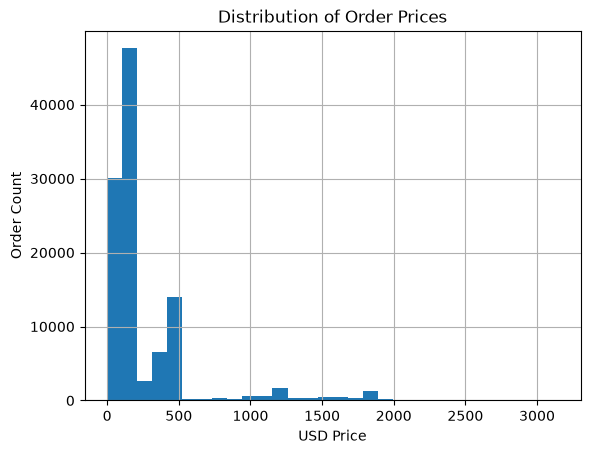

In [25]:
# USD price distribution
orders_clean["USD_PRICE"].hist(bins=30)

plt.xlabel("USD Price")
plt.ylabel("Order Count")
plt.title("Distribution of Order Prices")
plt.show()

Order prices are heavily right-skewed and concentrated around a small number of product price points.

In [26]:
orders_clean["PRODUCT_NAME_CLEANED"].value_counts()

PRODUCT_NAME_CLEANED
Apple Airpods Headphones       48404
27in 4K gaming monitor         23408
Samsung Charging Cable Pack    21923
Samsung Webcam                  7197
Macbook Air Laptop              3964
ThinkPad Laptop                 2916
Apple iPhone                     288
Bose Soundsport Headphones        27
Name: count, dtype: int64

In [27]:
# Categorical distributions
orders_clean["REGION"].value_counts(dropna=False)

REGION
NA       55812
EMEA     31816
APAC     13103
LATAM     7252
NaN        144
Name: count, dtype: int64

In [28]:
orders_clean["LOYALTY_PROGRAM"].value_counts()

LOYALTY_PROGRAM
0    62434
1    45693
Name: count, dtype: int64

In [29]:
orders_clean["PURCHASE_PLATFORM"].value_counts()

PURCHASE_PLATFORM
website       89610
mobile app    18517
Name: count, dtype: int64

In [30]:
orders_clean["MARKETING_CHANNEL_CLEANED"].value_counts()

MARKETING_CHANNEL_CLEANED
direct          83912
email           18553
affiliate        2900
unknown          1469
social media     1293
Name: count, dtype: int64

In [31]:
orders_clean["ACCOUNT_CREATION_METHOD_CLEANED"].value_counts()

ACCOUNT_CREATION_METHOD_CLEANED
desktop    83912
mobile     18553
unknown     4287
tablet      1293
tv            82
Name: count, dtype: int64

In [32]:
pd.crosstab(
    orders_clean["MARKETING_CHANNEL_CLEANED"],
    orders_clean["ACCOUNT_CREATION_METHOD_CLEANED"]
)

ACCOUNT_CREATION_METHOD_CLEANED,desktop,mobile,tablet,tv,unknown
MARKETING_CHANNEL_CLEANED,,,,,
affiliate,0,0,0,0,2900
direct,83912,0,0,0,0
email,0,18553,0,0,0
social media,0,0,1293,0,0
unknown,0,0,0,82,1387


**EDA summary:** The cleaned dataset contains 108K orders with no duplicate order IDs. Remaining missing values and date anomalies are limited and documented. Order volume is concentrated in a few products and regions, and marketing channel is strongly tied to account creation method, so those dimensions should not be treated as independent.

## 4. Business Questions

### 4.1 Overall Sales Trends

**Question:** What were the overall sales trends from 2019–2022?

**Analysis focus:** Examine order count, total sales, and AOV over time; compare performance by product and geography; and identify high/low periods and possible seasonality.

**Data note:** 3 orders with unknown purchase dates were excluded from time-based analysis. These orders totaled $358 in sales with an AOV of $119.

#### Monthly Performance

In [33]:
# Monthly performance
monthly_performance = orders_clean.groupby(["PURCHASE_YEAR", "PURCHASE_MONTH"], as_index=False).agg({
    "USD_PRICE": ["sum", "mean"],
    "ORDER_ID": "count"
})

monthly_performance.columns = [
    "PURCHASE_YEAR",
    "PURCHASE_MONTH",
    "TOTAL_SALES",
    "AOV",
    "ORDER_COUNT"
]

# Monthly date
monthly_performance["PURCHASE_DATE"] = pd.to_datetime({
    "year": monthly_performance["PURCHASE_YEAR"],
    "month": monthly_performance["PURCHASE_MONTH"],
    "day": 1
})

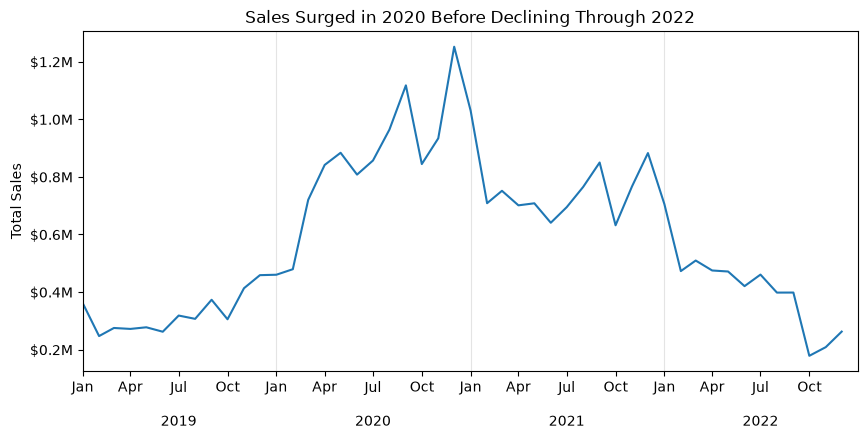

In [106]:
# Monthly total sales
plt.figure(figsize=(10, 5))
ax = plt.gca()
format_monthly_axis(ax)
plt.plot(monthly_performance["PURCHASE_DATE"], monthly_performance["TOTAL_SALES"])

plt.ylabel("Total Sales")
plt.title("Sales Surged in 2020 Before Declining Through 2022")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x / 1_000_000:.1f}M")
)

plt.savefig("images/monthly_sales.png", dpi=150, bbox_inches="tight")

plt.show()

Monthly sales climbed through 2019 and accelerated sharply in 2020, peaking at about $1.25M in December 2020 before declining through 2021 and 2022.

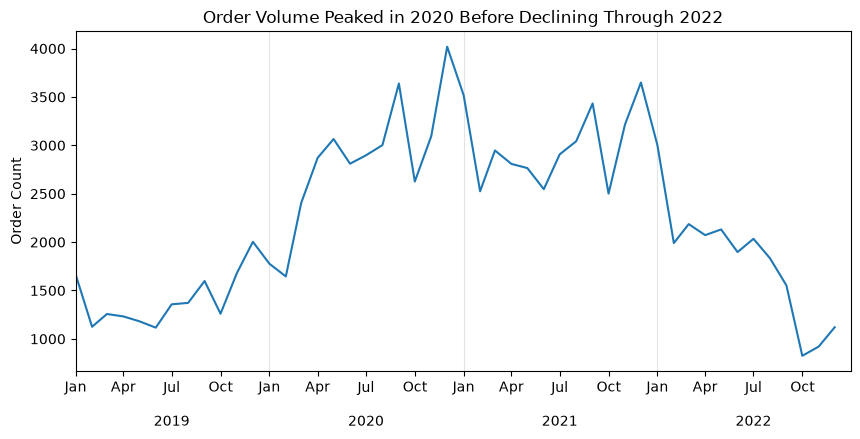

In [35]:
# Monthly order count
plt.figure(figsize=(10, 5))
ax = plt.gca()
format_monthly_axis(ax)
plt.plot(monthly_performance["PURCHASE_DATE"], monthly_performance["ORDER_COUNT"])

plt.ylabel("Order Count")
plt.title("Order Volume Peaked in 2020 Before Declining Through 2022")

plt.show()

Order volume followed a similar pattern to total sales, rising sharply through 2020 before declining in 2021 and 2022.

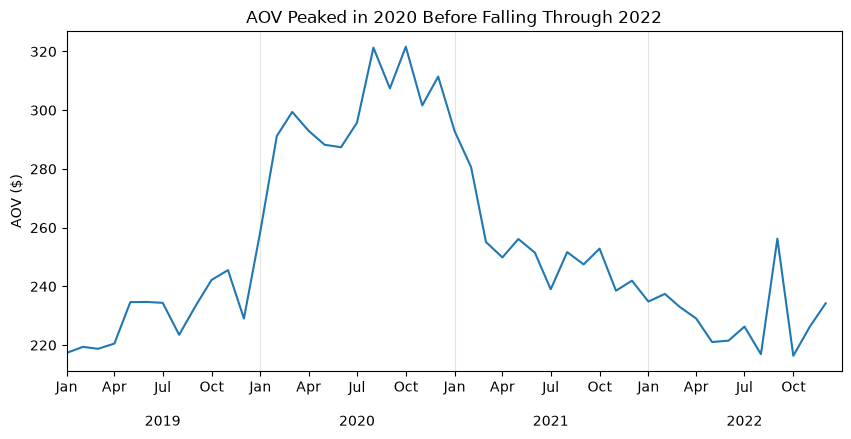

In [36]:
# Monthly AOV
plt.figure(figsize=(10, 5))
ax = plt.gca()
format_monthly_axis(ax)
plt.plot(monthly_performance["PURCHASE_DATE"], monthly_performance["AOV"])

plt.ylabel("AOV ($)")
plt.title("AOV Peaked in 2020 Before Falling Through 2022")

plt.show()

AOV rose sharply in 2020, reaching about $320 at its peak, before steadily declining through 2021 and 2022.

The 2020 sales surge was driven by both higher order volume and a shift toward higher-value products. The decline that followed reflects deterioration in both order volume and AOV, although falling order volume became the larger driver by 2022.

In [37]:
# Monthly highlights
sales_max = monthly_performance["TOTAL_SALES"].idxmax()
aov_max = monthly_performance["AOV"].idxmax()
count_max = monthly_performance["ORDER_COUNT"].idxmax()

monthly_highlights = pd.DataFrame({
    "METRIC": ["Total Sales", "AOV", "Order Count"],
    "MAX_VALUE": [
        f'${monthly_performance.loc[sales_max, "TOTAL_SALES"]:,.0f}',
        f'${monthly_performance.loc[aov_max, "AOV"]:,.0f}',
        f'{monthly_performance.loc[count_max, "ORDER_COUNT"]:,.0f}'
    ],
    "MONTH": [
        monthly_performance.loc[sales_max, "PURCHASE_DATE"].strftime("%b %Y"),
        monthly_performance.loc[aov_max, "PURCHASE_DATE"].strftime("%b %Y"),
        monthly_performance.loc[count_max, "PURCHASE_DATE"].strftime("%b %Y")
    ]
})

monthly_highlights

,METRIC,MAX_VALUE,MONTH
0,Total Sales,"$1,251,721",Dec 2020
1,AOV,$322,Oct 2020
2,Order Count,"4,019",Dec 2020


##### Seasonality

In [38]:
# Normalize monthly sales to each year's monthly average
seasonality = monthly_performance.copy()

seasonality["SALES_INDEX"] = (
    seasonality["TOTAL_SALES"] /
    seasonality.groupby("PURCHASE_YEAR")["TOTAL_SALES"].transform("mean")
)

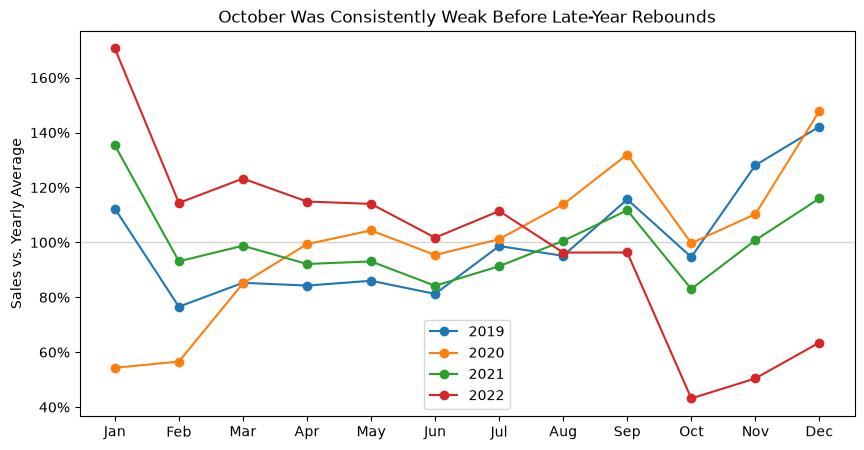

In [39]:
# Sales seasonality by year
plt.figure(figsize=(10, 5))

for year in seasonality["PURCHASE_YEAR"].unique():
    year_data = seasonality[seasonality["PURCHASE_YEAR"] == year]

    plt.plot(
        year_data["PURCHASE_MONTH"],
        year_data["SALES_INDEX"],
        marker="o",
        label=str(year),
        zorder=3
    )

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.axhline(1, color="lightgray", linewidth=1, zorder=0)

plt.ylabel("Sales vs. Yearly Average")
plt.title("October Was Consistently Weak Before Late-Year Rebounds")
plt.legend()

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.show()

October underperformed relative to surrounding months each year, followed by rebounds in November and December. This suggests a recurring late-year seasonal pattern, although the broader 2022 decline weakened the rebound.

In [40]:
# Remove the long-term trend using a centered 12-month rolling average
seasonality["SALES_TREND"] = (
    seasonality["TOTAL_SALES"]
    .rolling(window=12, center=True)
    .mean()
)

seasonality["DETREND_SALES"] = (
    seasonality["TOTAL_SALES"] / seasonality["SALES_TREND"]
)

In [41]:
# Remove long-term order count and AOV trends
seasonality["ORDER_COUNT_TREND"] = (
    seasonality["ORDER_COUNT"]
    .rolling(window=12, center=True)
    .mean()
)

seasonality["AOV_TREND"] = (
    seasonality["AOV"]
    .rolling(window=12, center=True)
    .mean()
)

seasonality["DETREND_ORDER_COUNT"] = (
    seasonality["ORDER_COUNT"] / seasonality["ORDER_COUNT_TREND"]
)

seasonality["DETREND_AOV"] = (
    seasonality["AOV"] / seasonality["AOV_TREND"]
)

In [42]:
seasonal_comparison = seasonality.groupby("PURCHASE_MONTH", as_index=False).agg({
    "DETREND_SALES": "mean",
    "DETREND_ORDER_COUNT": "mean",
    "DETREND_AOV": "mean"
})

seasonal_comparison["MONTH"] = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

seasonal_comparison

,PURCHASE_MONTH,DETREND_SALES,DETREND_ORDER_COUNT,DETREND_AOV,MONTH
0,1,1.049986,1.059758,1.000891,Jan
1,2,0.806572,0.792209,1.031619,Feb
2,3,0.966431,0.971609,1.004793,Mar
3,4,0.977043,1.000553,0.981627,Apr
4,5,0.999617,1.032323,0.975250,May
5,6,0.916015,0.949223,0.971627,Jun
6,7,1.006399,1.024513,0.984527,Jul
7,8,1.016139,1.005238,1.011399,Aug
8,9,1.159841,1.159273,1.001991,Sep
9,10,0.873613,0.848168,1.035111,Oct


In [43]:
# Convert seasonal indexes to percent above/below trend
seasonal_comparison["SALES_VS_TREND"] = seasonal_comparison["DETREND_SALES"] - 1
seasonal_comparison["ORDER_COUNT_VS_TREND"] = seasonal_comparison["DETREND_ORDER_COUNT"] - 1
seasonal_comparison["AOV_VS_TREND"] = seasonal_comparison["DETREND_AOV"] - 1

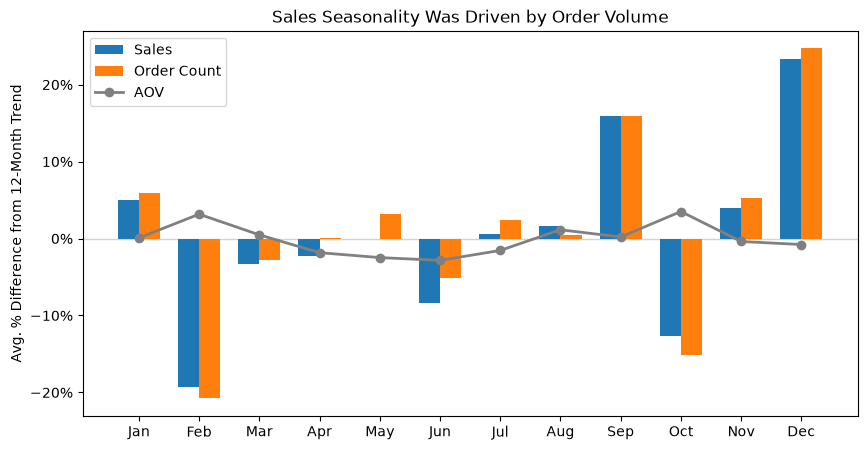

In [111]:
x = range(len(seasonal_comparison))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    [i - width / 2 for i in x],
    seasonal_comparison["SALES_VS_TREND"],
    width=width,
    label="Sales"
)

plt.bar(
    [i + width / 2 for i in x],
    seasonal_comparison["ORDER_COUNT_VS_TREND"],
    width=width,
    label="Order Count"
)

plt.plot(
    x,
    seasonal_comparison["AOV_VS_TREND"],
    marker="o",
    linewidth=2,
    color="gray",
    label="AOV"
)

plt.xticks(x, seasonal_comparison["MONTH"])
plt.axhline(0, color="lightgray", linewidth=1, zorder=0)

plt.ylabel("Avg. % Difference from 12-Month Trend")
plt.title("Sales Seasonality Was Driven by Order Volume")

handles, labels = plt.gca().get_legend_handles_labels()
order = [1, 2, 0]

plt.legend(
    [handles[i] for i in order],
    [labels[i] for i in order]
)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.savefig("images/seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

After removing the long-term trend using a centered 12-month rolling average, sales and order count followed nearly the same seasonal pattern while AOV remained relatively stable. December and September averaged the strongest performance above trend, while February and October were the weakest months.

This indicates that Elist's seasonal sales swings were driven primarily by changes in order volume rather than changes in how much customers spent per order. Since the dataset covers only four years, the pattern should be treated as directional rather than definitive.

In [45]:
# Product order seasonality
product_seasonality = orders_clean.groupby(
    ["PURCHASE_YEAR", "PURCHASE_MONTH", "PRODUCT_NAME_CLEANED"],
    as_index=False
).agg({
    "ORDER_ID": "count"
})

product_seasonality = product_seasonality.rename(columns={
    "ORDER_ID": "ORDER_COUNT"
})

# Compare each product-month with that product's average month for the year
product_seasonality["ORDER_INDEX"] = (
    product_seasonality["ORDER_COUNT"] /
    product_seasonality.groupby(
        ["PURCHASE_YEAR", "PRODUCT_NAME_CLEANED"]
    )["ORDER_COUNT"].transform("mean")
)

product_seasonality_summary = product_seasonality.groupby(
    ["PURCHASE_MONTH", "PRODUCT_NAME_CLEANED"],
    as_index=False
)["ORDER_INDEX"].mean()

product_seasonality_summary[
    product_seasonality_summary["PURCHASE_MONTH"].isin([2, 9, 10, 12])
].pivot(
    index="PRODUCT_NAME_CLEANED",
    columns="PURCHASE_MONTH",
    values="ORDER_INDEX"
)

PURCHASE_MONTH,2,9,10,12
PRODUCT_NAME_CLEANED,,,,
27in 4K gaming monitor,0.835662,1.207943,0.845773,1.226133
Apple Airpods Headphones,0.843954,1.086230,0.755789,1.147166
Apple iPhone,0.913597,1.154251,0.984112,1.177287
Bose Soundsport Headphones,0.588235,0.588235,0.683007,1.176471
Macbook Air Laptop,0.899189,1.051806,0.894264,1.180984
Samsung Charging Cable Pack,0.812274,1.053979,0.760680,1.103867
Samsung Webcam,0.751240,1.224848,0.908988,1.491206
ThinkPad Laptop,0.719373,1.273918,0.651453,1.147562


In [46]:
# Product contribution to seasonal sales changes
product_monthly_sales = orders_clean.dropna(subset=["PURCHASE_TS_CLEANED"])

product_monthly_sales = product_monthly_sales.groupby(
    ["PURCHASE_YEAR", "PURCHASE_MONTH", "PRODUCT_NAME_CLEANED"],
    as_index=False
)["USD_PRICE"].sum()

product_monthly_sales = product_monthly_sales.rename(
    columns={"USD_PRICE": "SALES"}
)

product_monthly_sales["MONTHLY_AVG"] = product_monthly_sales.groupby(
    ["PURCHASE_YEAR", "PRODUCT_NAME_CLEANED"]
)["SALES"].transform("mean")

product_monthly_sales["SALES_VS_AVG"] = (
    product_monthly_sales["SALES"] - product_monthly_sales["MONTHLY_AVG"]
)

key_months = product_monthly_sales[
    product_monthly_sales["PURCHASE_MONTH"].isin([2, 9, 10, 12])
]

product_seasonality_drivers = key_months.groupby(
    ["PURCHASE_MONTH", "PRODUCT_NAME_CLEANED"],
    as_index=False
)["SALES_VS_AVG"].sum()

product_seasonality_drivers.sort_values(
    ["PURCHASE_MONTH", "SALES_VS_AVG"],
    ascending=[True, False]
)

,PURCHASE_MONTH,PRODUCT_NAME_CLEANED,SALES_VS_AVG
3,2,Bose Soundsport Headphones,-107.446000
2,2,Apple iPhone,-1815.486136
6,2,Samsung Webcam,-4321.926667
5,2,Samsung Charging Cable Pack,-7294.372500
7,2,ThinkPad Laptop,-71817.808333
4,2,Macbook Air Laptop,-88685.677500
1,2,Apple Airpods Headphones,-119122.611667
0,2,27in 4K gaming monitor,-143121.123333
8,9,27in 4K gaming monitor,179724.006667
15,9,ThinkPad Laptop,73806.191667


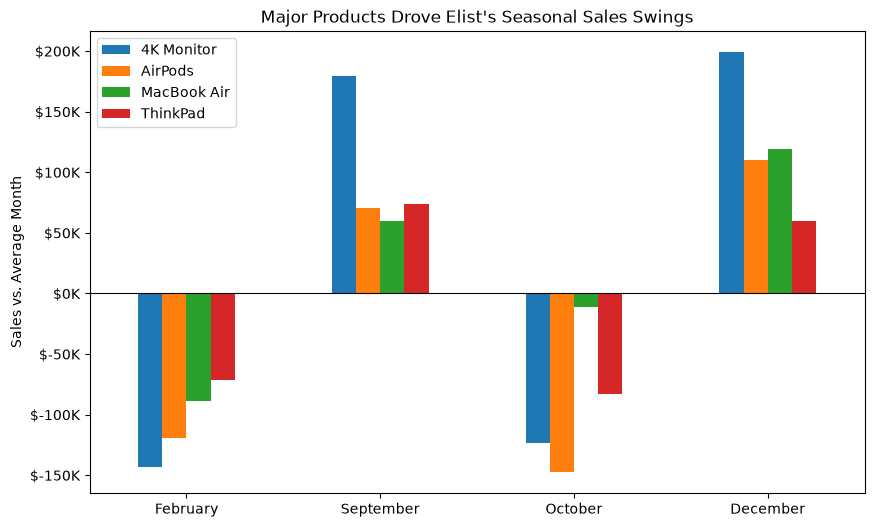

In [47]:
# Seasonal sales contribution by major product
major_products = [
    "27in 4K gaming monitor",
    "Apple Airpods Headphones",
    "Macbook Air Laptop",
    "ThinkPad Laptop"
]

seasonality_plot = product_seasonality_drivers[
    product_seasonality_drivers["PRODUCT_NAME_CLEANED"].isin(major_products)
].copy()

seasonality_plot["MONTH"] = seasonality_plot["PURCHASE_MONTH"].map({
    2: "February",
    9: "September",
    10: "October",
    12: "December"
})

seasonality_plot["PRODUCT"] = seasonality_plot["PRODUCT_NAME_CLEANED"].replace({
    "27in 4K gaming monitor": "4K Monitor",
    "Apple Airpods Headphones": "AirPods",
    "Macbook Air Laptop": "MacBook Air",
    "ThinkPad Laptop": "ThinkPad"
})

seasonality_plot = seasonality_plot.pivot(
    index="MONTH",
    columns="PRODUCT",
    values="SALES_VS_AVG"
)

seasonality_plot = seasonality_plot.reindex([
    "February",
    "September",
    "October",
    "December"
])

seasonality_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Sales vs. Average Month")
plt.xlabel("")
plt.title("Major Products Drove Elist's Seasonal Sales Swings")
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1000:.0f}K")
)

plt.legend(title="")
plt.show()

The seasonal pattern appeared across most major products, but the largest sales swings came from Elist's highest-revenue products. The 4K gaming monitor contributed nearly half of September's above-normal sales and was also the largest contributor to December strength. October weakness was concentrated primarily in AirPods and the 4K monitor.

December strength is consistent with the winter holiday shopping season, while September may partly reflect back-to-school and college demand. These external patterns provide plausible context for Elist's seasonality but do not establish causation.

The recurring October weakness does not have a clear explanation from the available data.

#### Yearly Performance

In [48]:
# Yearly performance
yearly_performance = orders_clean.groupby("PURCHASE_YEAR", as_index=False).agg({
    "USD_PRICE": ["sum", "mean"],
    "ORDER_ID": "count"
})

yearly_performance.columns = [
    "PURCHASE_YEAR",
    "TOTAL_SALES",
    "AOV",
    "ORDER_COUNT"
]

yearly_performance

,PURCHASE_YEAR,TOTAL_SALES,AOV,ORDER_COUNT
0,2019,3868907.48,229.636009,16850
1,2020,10158439.46,300.163681,33851
2,2021,9127894.44,254.705875,35858
3,2022,4957579.85,229.911415,21565


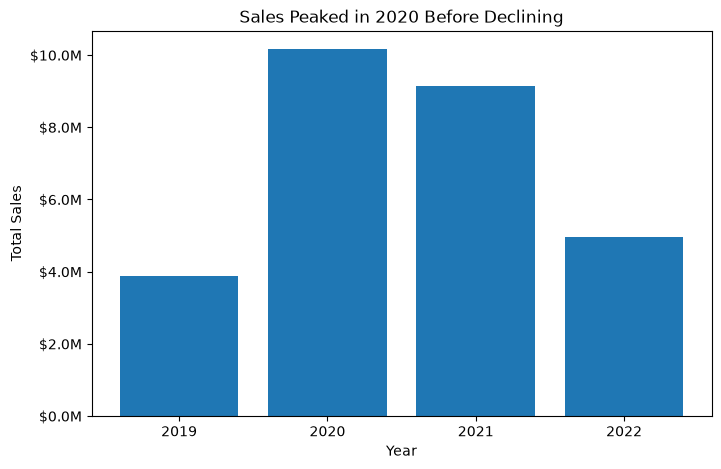

In [49]:
# Yearly total sales
plt.figure(figsize=(8, 5))
plt.bar(yearly_performance["PURCHASE_YEAR"].astype(str), yearly_performance["TOTAL_SALES"])

plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Sales Peaked in 2020 Before Declining")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x / 1_000_000:.1f}M")
)

plt.show()

Annual sales more than doubled from 2019 to 2020, then declined in 2021 and fell sharply again in 2022.

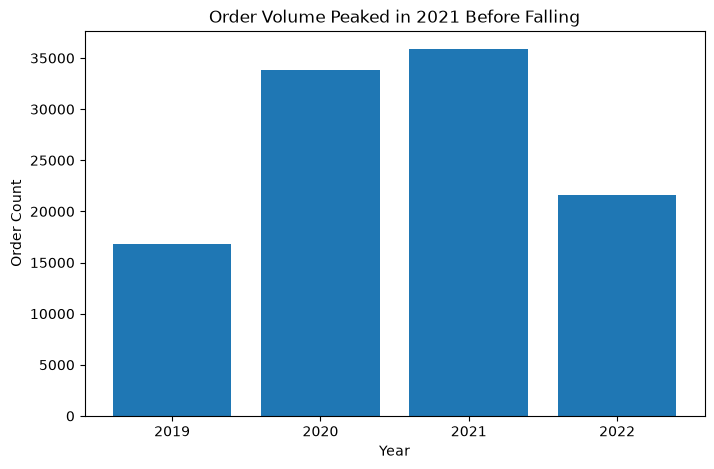

In [50]:
# Yearly order count
plt.figure(figsize=(8, 5))
plt.bar(yearly_performance["PURCHASE_YEAR"].astype(str), yearly_performance["ORDER_COUNT"])

plt.xlabel("Year")
plt.ylabel("Order Count")
plt.title("Order Volume Peaked in 2021 Before Falling")

plt.show()

Order volume continued to grow in 2021 even as total sales declined, suggesting that customers were making less expensive purchases on average.

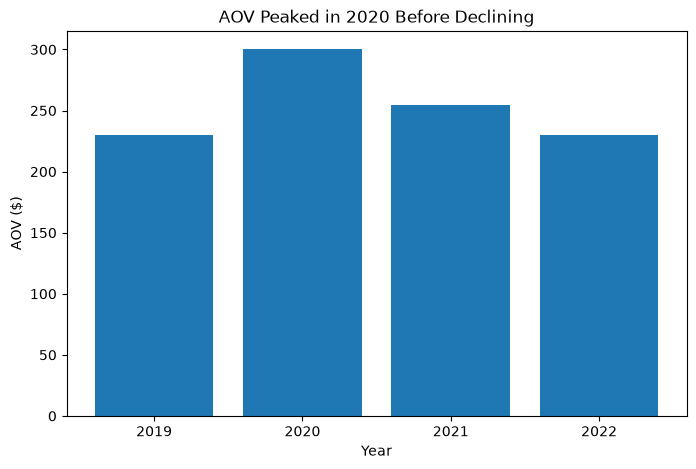

In [51]:
# Yearly AOV
plt.figure(figsize=(8, 5))
plt.bar(yearly_performance["PURCHASE_YEAR"].astype(str), yearly_performance["AOV"])

plt.xlabel("Year")
plt.ylabel("AOV ($)")
plt.title("AOV Peaked in 2020 Before Declining")

plt.show()

AOV fell from about $300 in 2020 to $255 in 2021, explaining why total sales declined even though order volume continued to grow.

Overall, 2020 was Elist's strongest sales year because both order volume and AOV were high. Orders continued growing in 2021, but customers made lower-value purchases, reducing total sales. In 2022, both order volume and AOV declined.

##### Drivers of Yearly Performance

###### 2020 Growth Drivers

In [52]:
# Product mix by year
product_mix = orders_clean.groupby(["PURCHASE_YEAR", "PRODUCT_NAME_CLEANED"], as_index=False).agg({
    "ORDER_ID": "count"
})

product_mix = product_mix.rename(columns={
    "ORDER_ID": "ORDER_COUNT"
})

product_mix["YEARLY_ORDER_COUNT"] = product_mix.groupby("PURCHASE_YEAR")["ORDER_COUNT"].transform("sum")
product_mix["ORDER_SHARE"] = product_mix["ORDER_COUNT"] / product_mix["YEARLY_ORDER_COUNT"]

In [53]:
# Change in product mix between years
product_mix_change = product_mix.pivot(
    index="PRODUCT_NAME_CLEANED",
    columns="PURCHASE_YEAR",
    values="ORDER_SHARE"
).fillna(0)

product_mix_change["CHANGE_2019_2020"] = (
    product_mix_change[2020] - product_mix_change[2019]
)

product_mix_change["CHANGE_2020_2021"] = (
    product_mix_change[2021] - product_mix_change[2020]
)

product_mix_change[[
    2019,
    2020,
    2021,
    "CHANGE_2019_2020",
    "CHANGE_2020_2021"
]].sort_values("CHANGE_2019_2020", ascending=False)

PURCHASE_YEAR,2019,2020,2021,CHANGE_2019_2020,CHANGE_2020_2021
PRODUCT_NAME_CLEANED,,,,,
Samsung Webcam,0.000000,0.043101,0.094289,0.043101,0.051188
Macbook Air Laptop,0.021721,0.054504,0.033047,0.032782,-0.021457
ThinkPad Laptop,0.021484,0.034238,0.025685,0.012755,-0.008554
27in 4K gaming monitor,0.213353,0.219196,0.215573,0.005843,-0.003623
Apple iPhone,0.002730,0.003634,0.002119,0.000904,-0.001514
Bose Soundsport Headphones,0.000000,0.000502,0.000251,0.000502,-0.000251
Apple Airpods Headphones,0.484451,0.472601,0.425428,-0.011851,-0.047172
Samsung Charging Cable Pack,0.256261,0.172225,0.203609,-0.084036,0.031383


In [54]:
# AOV by product and year
product_aov_year = orders_clean.groupby(
    ["PURCHASE_YEAR", "PRODUCT_NAME_CLEANED"],
    as_index=False
).agg({
    "USD_PRICE": "mean"
})

product_aov_year = product_aov_year.pivot(
    index="PRODUCT_NAME_CLEANED",
    columns="PURCHASE_YEAR",
    values="USD_PRICE"
)

product_aov_year

PURCHASE_YEAR,2019,2020,2021,2022
PRODUCT_NAME_CLEANED,,,,
27in 4K gaming monitor,402.943293,416.863251,434.096577,418.930088
Apple Airpods Headphones,157.432250,159.470136,162.781755,157.992775
Apple iPhone,741.302826,748.857236,744.409737,710.304186
Bose Soundsport Headphones,NaN,124.580000,124.355556,101.980000
Macbook Air Laptop,1657.789126,1591.593149,1603.225232,1500.435440
Samsung Charging Cable Pack,22.450871,22.499648,18.311233,18.114831
Samsung Webcam,NaN,50.376906,50.710240,50.066820
ThinkPad Laptop,1097.950746,1103.644866,1115.282595,1060.249747


In [55]:
# Product sales change from 2019 to 2020
product_sales_year = orders_clean.groupby(
    ["PURCHASE_YEAR", "PRODUCT_NAME_CLEANED"],
    as_index=False
).agg({
    "USD_PRICE": "sum"
})

product_sales_change = product_sales_year.pivot(
    index="PRODUCT_NAME_CLEANED",
    columns="PURCHASE_YEAR",
    values="USD_PRICE"
).fillna(0)

product_sales_change["CHANGE_2019_2020"] = (
    product_sales_change[2020] - product_sales_change[2019]
)

product_sales_change[[
    2019,
    2020,
    "CHANGE_2019_2020"
]].sort_values("CHANGE_2019_2020", ascending=False)

PURCHASE_YEAR,2019,2020,CHANGE_2019_2020
PRODUCT_NAME_CLEANED,,,
Macbook Air Laptop,606750.82,2936489.36,2329738.54
27in 4K gaming monitor,1448581.14,3093125.32,1644544.18
Apple Airpods Headphones,1285119.46,2551203.24,1266083.78
ThinkPad Laptop,397458.17,1279124.40,881666.23
Samsung Webcam,0.00,73096.89,73096.89
Apple iPhone,34099.93,92109.44,58009.51
Samsung Charging Cable Pack,96897.96,131172.95,34274.99
Bose Soundsport Headphones,0.00,2117.86,2117.86


Elist's 2020 sales surge was driven by sharply higher order volume and a shift toward higher-value products, particularly computers and monitors. Within-product prices remained relatively stable, indicating that the increase in AOV was primarily driven by product mix rather than price increases.

The acceleration in demand coincided with the pandemic-driven expansion in e-commerce and remote work, suggesting those broader changes likely contributed to Elist's growth. However, the Elist data alone cannot establish causation.

In [56]:
# First and last purchase dates by product
product_sales_period = orders_clean.groupby(
    "PRODUCT_NAME_CLEANED",
    as_index=False
).agg({
    "PURCHASE_TS_CLEANED": ["min", "max"],
    "ORDER_ID": "count"
})

product_sales_period.columns = [
    "PRODUCT_NAME",
    "FIRST_PURCHASE",
    "LAST_PURCHASE",
    "ORDER_COUNT"
]

product_sales_period.sort_values("FIRST_PURCHASE")

,PRODUCT_NAME,FIRST_PURCHASE,LAST_PURCHASE,ORDER_COUNT
0,27in 4K gaming monitor,2019-01-01,2022-12-31,23408
1,Apple Airpods Headphones,2019-01-01,2022-12-31,48404
4,Macbook Air Laptop,2019-01-01,2022-12-31,3964
5,Samsung Charging Cable Pack,2019-01-01,2022-12-31,21923
7,ThinkPad Laptop,2019-01-02,2022-12-31,2916
2,Apple iPhone,2019-01-05,2022-12-30,288
6,Samsung Webcam,2020-01-29,2022-12-30,7197
3,Bose Soundsport Headphones,2020-02-11,2022-11-23,27


Most of Elist's core products were sold throughout the full analysis period. Samsung Webcam first appears in the order data in January 2020, so part of its subsequent growth reflects product assortment expansion rather than organic demand growth. However, the new products represented too little sales volume to explain Elist's broader 2020 surge.

###### 2022 Decline Drivers

In [57]:
# Product sales change from 2021 to 2022
product_sales_change["CHANGE_2021_2022"] = (
    product_sales_change[2022] - product_sales_change[2021]
)

product_sales_change[[
    2021,
    2022,
    "CHANGE_2021_2022"
]].sort_values("CHANGE_2021_2022")

PURCHASE_YEAR,2021,2022,CHANGE_2021_2022
PRODUCT_NAME_CLEANED,,,
27in 4K gaming monitor,3355566.54,1953471.00,-1402095.54
Apple Airpods Headphones,2483235.68,1419723.08,-1063512.60
Macbook Air Laptop,1899821.90,852247.33,-1047574.57
ThinkPad Laptop,1027175.27,502558.38,-524616.89
Samsung Webcam,170893.51,117907.36,-52986.15
Samsung Charging Cable Pack,133507.20,81027.64,-52479.56
Apple iPhone,56575.14,30543.08,-26032.06
Bose Soundsport Headphones,1119.20,101.98,-1017.22


In [58]:
# Product order count and AOV changes from 2021 to 2022
product_change_2022 = orders_clean[
    orders_clean["PURCHASE_YEAR"].isin([2021, 2022])
].groupby(
    ["PRODUCT_NAME_CLEANED", "PURCHASE_YEAR"],
    as_index=False
).agg({
    "ORDER_ID": "count",
    "USD_PRICE": "mean"
})

product_change_2022.columns = [
    "PRODUCT_NAME",
    "PURCHASE_YEAR",
    "ORDER_COUNT",
    "AOV"
]

order_change = product_change_2022.pivot(
    index="PRODUCT_NAME",
    columns="PURCHASE_YEAR",
    values="ORDER_COUNT"
)

aov_change = product_change_2022.pivot(
    index="PRODUCT_NAME",
    columns="PURCHASE_YEAR",
    values="AOV"
)

product_2022_drivers = pd.DataFrame({
    "ORDER_GROWTH": order_change[2022] / order_change[2021] - 1,
    "AOV_GROWTH": aov_change[2022] / aov_change[2021] - 1
})

product_2022_drivers

,ORDER_GROWTH,AOV_GROWTH
PRODUCT_NAME,,
27in 4K gaming monitor,-0.396766,-0.034938
Apple Airpods Headphones,-0.410947,-0.029420
Apple iPhone,-0.434211,-0.045816
Bose Soundsport Headphones,-0.888889,-0.179932
Macbook Air Laptop,-0.520675,-0.064114
Samsung Charging Cable Pack,-0.387344,-0.010726
Samsung Webcam,-0.302869,-0.012688
ThinkPad Laptop,-0.485342,-0.049344


In [59]:
# Monthly performance: 2022 vs. 2021
monthly_2022_change = monthly_performance[
    monthly_performance["PURCHASE_YEAR"].isin([2021, 2022])
].pivot(
    index="PURCHASE_MONTH",
    columns="PURCHASE_YEAR",
    values=["TOTAL_SALES", "ORDER_COUNT", "AOV"]
)

monthly_2022_change["SALES_GROWTH"] = (
    monthly_2022_change["TOTAL_SALES"][2022] /
    monthly_2022_change["TOTAL_SALES"][2021] - 1
)

monthly_2022_change["ORDER_GROWTH"] = (
    monthly_2022_change["ORDER_COUNT"][2022] /
    monthly_2022_change["ORDER_COUNT"][2021] - 1
)

monthly_2022_change["AOV_GROWTH"] = (
    monthly_2022_change["AOV"][2022] /
    monthly_2022_change["AOV"][2021] - 1
)

monthly_2022_change[[
    "SALES_GROWTH",
    "ORDER_GROWTH",
    "AOV_GROWTH"
]]

,SALES_GROWTH,ORDER_GROWTH,AOV_GROWTH
PURCHASE_YEAR,,,
PURCHASE_MONTH,,,
1,-0.315274,-0.146674,-0.198036
2,-0.332844,-0.211881,-0.153818
3,-0.322335,-0.258229,-0.086626
4,-0.322800,-0.262108,-0.083230
5,-0.334599,-0.229295,-0.136945
6,-0.343770,-0.255202,-0.119261
7,-0.337298,-0.300310,-0.053189
8,-0.479882,-0.397107,-0.138147


The 2022 decline was primarily an order-volume problem. Sales fell across every major product, while within-product AOV changed relatively little. The decline also worsened substantially during the second half of the year: by September through December, order volume was roughly 55%–71% below the same months in 2021.

The sharp 2022 slowdown coincided with a broader decline in consumer technology demand following the pandemic-era boom. U.S. consumer technology revenue fell about 8% in 2022, while global PC and monitor shipments declined particularly sharply late in the year. This timing closely matches Elist's worsening order decline during the second half of 2022.

High inflation may also have reduced discretionary purchasing power. However, Elist's late-2022 decline was substantially steeper than the broader technology market, suggesting that external conditions alone may not fully explain the slowdown.

#### Product Performance

In [60]:
# Product performance
product_performance = orders_clean.groupby("PRODUCT_NAME_CLEANED", as_index=False).agg({
    "USD_PRICE": ["sum", "mean"],
    "ORDER_ID": "count"
})

product_performance.columns = [
    "PRODUCT_NAME",
    "TOTAL_SALES",
    "AOV",
    "ORDER_COUNT"
]

product_performance = product_performance.sort_values("TOTAL_SALES", ascending=False)

product_performance

,PRODUCT_NAME,TOTAL_SALES,AOV,ORDER_COUNT
0,27in 4K gaming monitor,9850744.00,420.828093,23408
1,Apple Airpods Headphones,7739617.46,159.896237,48404
4,Macbook Air Laptop,6295309.41,1588.120436,3964
7,ThinkPad Laptop,3206316.22,1099.559746,2916
5,Samsung Charging Cable Pack,442627.71,20.201164,21923
6,Samsung Webcam,361897.76,50.431683,7197
2,Apple iPhone,213327.59,740.720799,288
3,Bose Soundsport Headphones,3339.04,123.668148,27


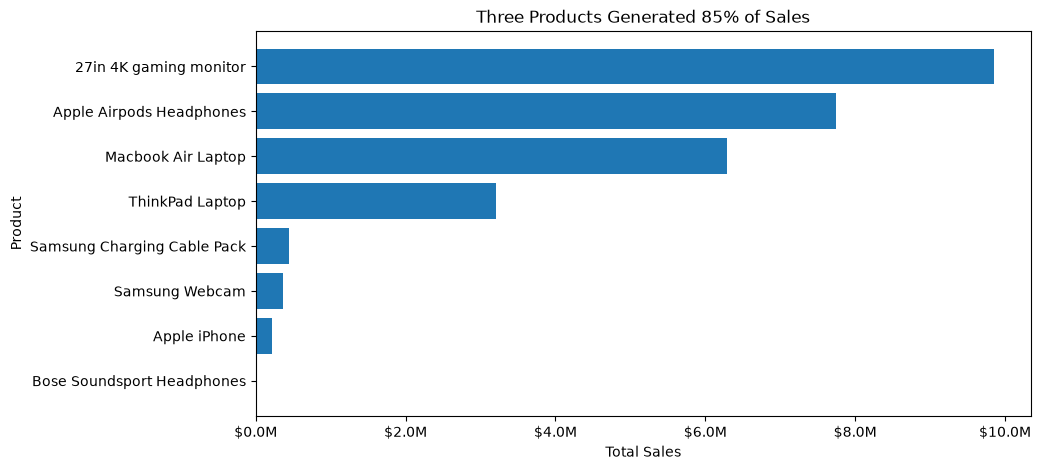

In [61]:
# Total sales by product
product_sales = product_performance.sort_values("TOTAL_SALES")

plt.figure(figsize=(10, 5))
plt.barh(product_sales["PRODUCT_NAME"], product_sales["TOTAL_SALES"])

plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.title("Three Products Generated 85% of Sales")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x / 1_000_000:.1f}M")
)

plt.show()

Sales were highly concentrated: the 4K monitor, AirPods, and MacBook Air accounted for about 85% of total revenue, led by the 4K monitor at $9.9M.

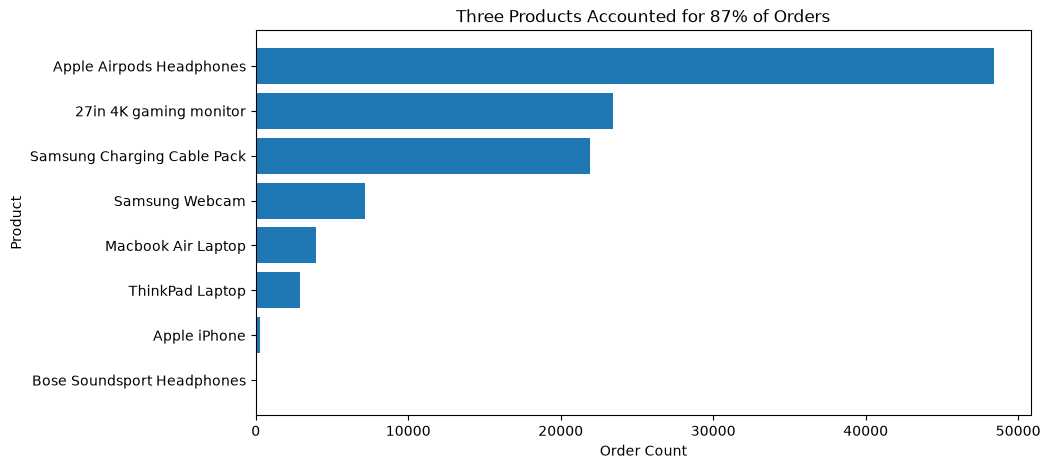

In [62]:
# Order count by product
product_orders = product_performance.sort_values("ORDER_COUNT")

plt.figure(figsize=(10, 5))
plt.barh(product_orders["PRODUCT_NAME"], product_orders["ORDER_COUNT"])

plt.xlabel("Order Count")
plt.ylabel("Product")
plt.title("Three Products Accounted for 87% of Orders")

plt.show()

Order volume was even more concentrated than revenue. AirPods, the 4K monitor, and Samsung charging cables accounted for about 87% of all orders, with AirPods alone representing nearly half.

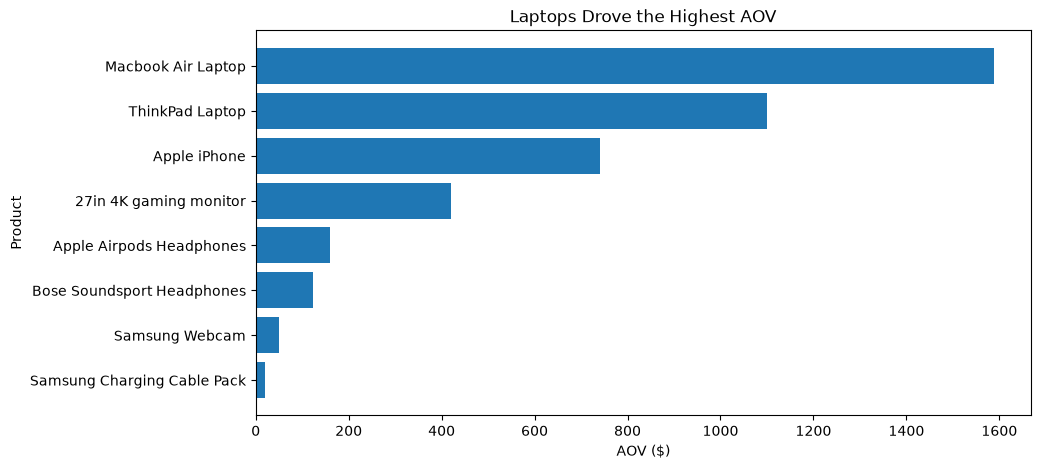

In [63]:
# AOV by product
product_aov = product_performance.sort_values("AOV")

plt.figure(figsize=(10, 5))
plt.barh(product_aov["PRODUCT_NAME"], product_aov["AOV"])

plt.xlabel("AOV ($)")
plt.ylabel("Product")
plt.title("Laptops Drove the Highest AOV")

plt.show()

MacBook Air had the highest AOV at about $1,588, followed by ThinkPad at about $1,100. These higher-value products generated substantial revenue despite relatively low order volume.

Product performance reflects a mix of volume and price. AirPods led order volume, while higher-priced products such as the 4K monitor and MacBook Air generated more revenue per order. The 4K monitor combined relatively high volume with a much higher AOV, making it Elist's top revenue-generating product.

#### Geographic Performance

In [64]:
# Geographic performance
geographic_performance = orders_clean.groupby("REGION", as_index=False).agg({
    "USD_PRICE": ["sum", "mean"],
    "ORDER_ID": "count"
})

geographic_performance.columns = [
    "REGION",
    "TOTAL_SALES",
    "AOV",
    "ORDER_COUNT"
]

geographic_performance = geographic_performance.sort_values("TOTAL_SALES", ascending=False)

# Region names
geographic_performance["REGION"] = geographic_performance["REGION"].replace({
    "NA": "North America",
    "EMEA": "Europe, Middle East & Africa",
    "APAC": "Asia-Pacific",
    "LATAM": "Latin America"
})

geographic_performance

,REGION,TOTAL_SALES,AOV,ORDER_COUNT
3,North America,14552372.32,260.739130,55812
1,"Europe, Middle East & Africa",8224211.25,258.704349,31816
0,Asia-Pacific,3652252.70,278.755358,13103
2,Latin America,1673815.25,230.998516,7252


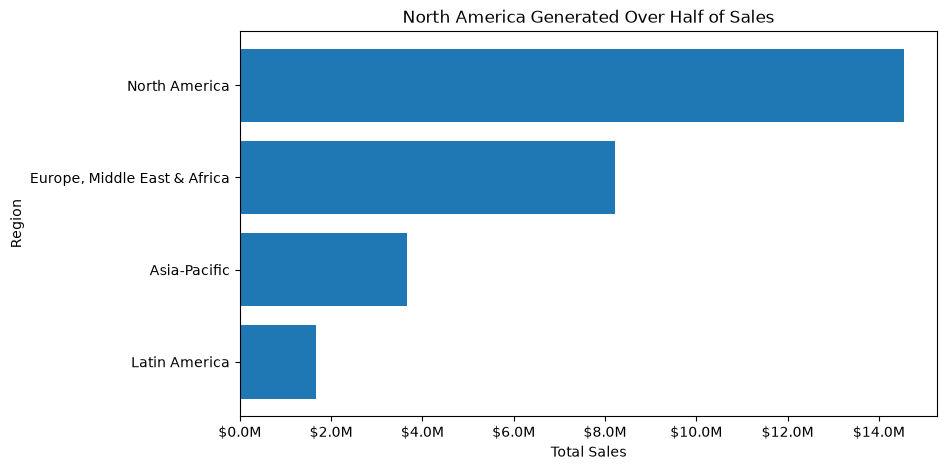

In [65]:
# Total sales by region
region_sales = geographic_performance.sort_values("TOTAL_SALES")

plt.figure(figsize=(9, 5))
plt.barh(region_sales["REGION"], region_sales["TOTAL_SALES"])

plt.xlabel("Total Sales")
plt.ylabel("Region")
plt.title("North America Generated Over Half of Sales")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x / 1_000_000:.1f}M")
)

plt.show()

North America was Elist's largest market, generating about $14.6M in sales—more than half of regional revenue.

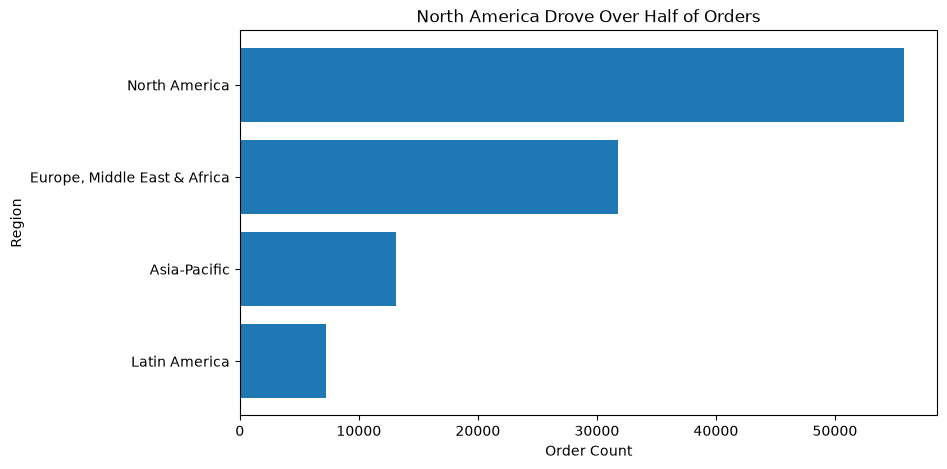

In [66]:
# Order count by region
region_orders = geographic_performance.sort_values("ORDER_COUNT")

plt.figure(figsize=(9, 5))
plt.barh(region_orders["REGION"], region_orders["ORDER_COUNT"])

plt.xlabel("Order Count")
plt.ylabel("Region")
plt.title("North America Drove Over Half of Orders")

plt.show()

Regional sales largely reflect order volume. North America accounted for over half of orders, followed by EMEA, while APAC and Latin America had substantially lower volume.

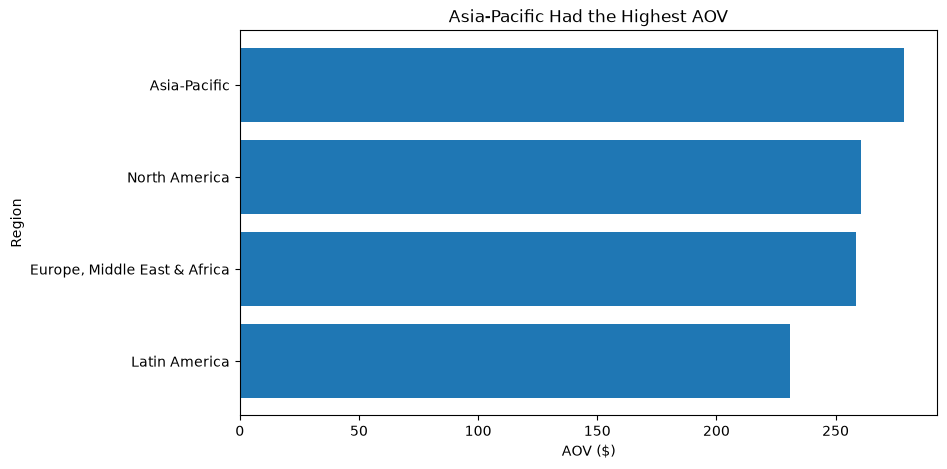

In [67]:
# AOV by region
region_aov = geographic_performance.sort_values("AOV")

plt.figure(figsize=(9, 5))
plt.barh(region_aov["REGION"], region_aov["AOV"])

plt.xlabel("AOV ($)")
plt.ylabel("Region")
plt.title("Asia-Pacific Had the Highest AOV")

plt.show()

Asia-Pacific had the highest AOV at about $279, while North America and EMEA were both around $260. Latin America had the lowest AOV at about $231.

Overall, regional revenue differences were driven primarily by order volume rather than AOV. North America dominated sales because it generated far more orders, while AOV was relatively similar across the major regions.

### 4.2 Monthly and Yearly Growth Rates

**Question:** What were the monthly and yearly growth rates?

**Stakeholder clarification:** Focus growth rates on total sales, AOV, and order count.

#### Monthly Growth

In [68]:
# Monthly growth rates
monthly_growth = monthly_performance.copy()

monthly_growth["SALES_GROWTH"] = monthly_growth["TOTAL_SALES"].pct_change()
monthly_growth["AOV_GROWTH"] = monthly_growth["AOV"].pct_change()
monthly_growth["ORDER_COUNT_GROWTH"] = monthly_growth["ORDER_COUNT"].pct_change()

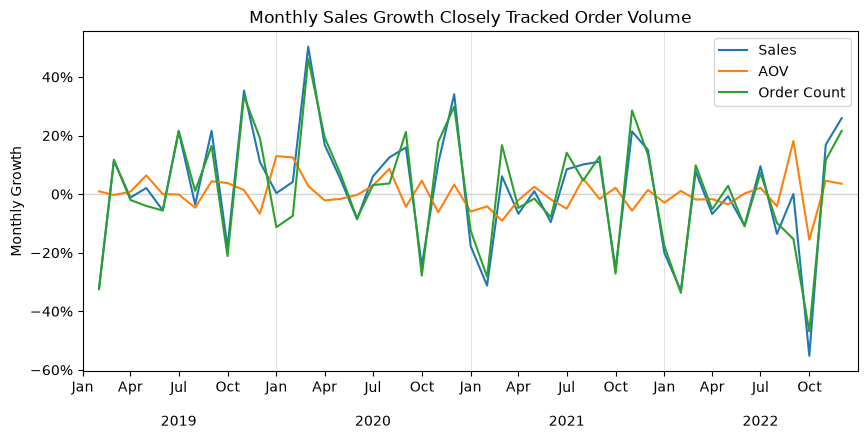

In [69]:
# Monthly growth rates
plt.figure(figsize=(10, 5))

ax = plt.gca()
format_monthly_axis(ax)

plt.plot(monthly_growth["PURCHASE_DATE"], monthly_growth["SALES_GROWTH"], label="Sales")
plt.plot(monthly_growth["PURCHASE_DATE"], monthly_growth["AOV_GROWTH"], label="AOV")
plt.plot(monthly_growth["PURCHASE_DATE"], monthly_growth["ORDER_COUNT_GROWTH"], label="Order Count")

plt.ylabel("Monthly Growth")
plt.title("Monthly Sales Growth Closely Tracked Order Volume")
plt.legend()
plt.axhline(0, color="lightgray", linewidth=1, zorder=0)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.show()

Month-to-month changes in sales closely followed changes in order volume, while AOV was comparatively stable. This suggests that short-term sales swings were driven primarily by how many orders customers placed rather than large changes in average purchase size.

#### Yearly Growth

In [70]:
# Yearly growth rates
yearly_growth = yearly_performance.copy()

yearly_growth["SALES_GROWTH"] = yearly_growth["TOTAL_SALES"].pct_change()
yearly_growth["AOV_GROWTH"] = yearly_growth["AOV"].pct_change()
yearly_growth["ORDER_COUNT_GROWTH"] = yearly_growth["ORDER_COUNT"].pct_change()

yearly_growth

,PURCHASE_YEAR,TOTAL_SALES,AOV,ORDER_COUNT,SALES_GROWTH,AOV_GROWTH,ORDER_COUNT_GROWTH
0,2019,3868907.48,229.636009,16850,NaN,NaN,NaN
1,2020,10158439.46,300.163681,33851,1.625661,0.307128,1.008961
2,2021,9127894.44,254.705875,35858,-0.101447,-0.151443,0.059289
3,2022,4957579.85,229.911415,21565,-0.456876,-0.097345,-0.398600


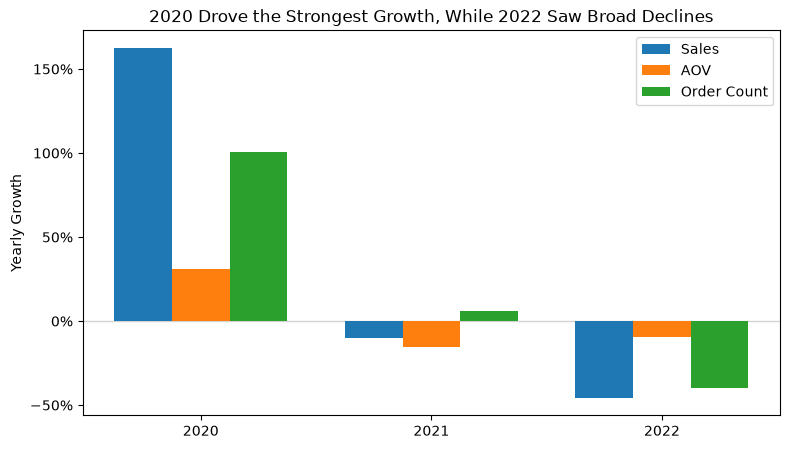

In [71]:
# Yearly growth rates
yearly_growth_plot = yearly_growth.dropna(subset=["SALES_GROWTH"]).copy()

x = range(len(yearly_growth_plot))
width = 0.25

plt.figure(figsize=(9, 5))

plt.bar([i - width for i in x], yearly_growth_plot["SALES_GROWTH"], width=width, label="Sales")
plt.bar(x, yearly_growth_plot["AOV_GROWTH"], width=width, label="AOV")
plt.bar([i + width for i in x], yearly_growth_plot["ORDER_COUNT_GROWTH"], width=width, label="Order Count")

plt.xticks(x, yearly_growth_plot["PURCHASE_YEAR"].astype(str))
plt.ylabel("Yearly Growth")
plt.title("2020 Drove the Strongest Growth, While 2022 Saw Broad Declines")
plt.legend()
plt.axhline(0, color="lightgray", linewidth=1, zorder=0)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.show()

2020 was Elist's strongest growth year, with sales more than doubling as both order volume and AOV increased. Growth weakened in 2021, and by 2022 all three metrics were declining.

Overall, changes in sales were driven more by order volume than AOV. Monthly sales growth closely followed order-count growth, while the yearly view shows a clear shift from rapid expansion in 2020 to broad declines by 2022.

### 4.3 Loyalty Program Performance

**Question:** How is the new loyalty program performing, and should Elist continue using it?

**Stakeholder clarification:** Compare loyalty and non-loyalty customers using total sales, order count, and AOV, with particular attention to how performance changes over time.

In [72]:
# Monthly loyalty performance
loyalty_performance = orders_clean.groupby(
    ["PURCHASE_YEAR", "PURCHASE_MONTH", "LOYALTY_PROGRAM"],
    as_index=False
).agg({
    "USD_PRICE": ["sum", "mean"],
    "ORDER_ID": "count"
})

loyalty_performance.columns = [
    "PURCHASE_YEAR",
    "PURCHASE_MONTH",
    "LOYALTY_PROGRAM",
    "TOTAL_SALES",
    "AOV",
    "ORDER_COUNT"
]

# Monthly date
loyalty_performance["PURCHASE_DATE"] = pd.to_datetime({
    "year": loyalty_performance["PURCHASE_YEAR"],
    "month": loyalty_performance["PURCHASE_MONTH"],
    "day": 1
})

# Readable loyalty labels
loyalty_performance["CUSTOMER_TYPE"] = loyalty_performance["LOYALTY_PROGRAM"].replace({
    0: "Regular",
    1: "Loyalty"
})

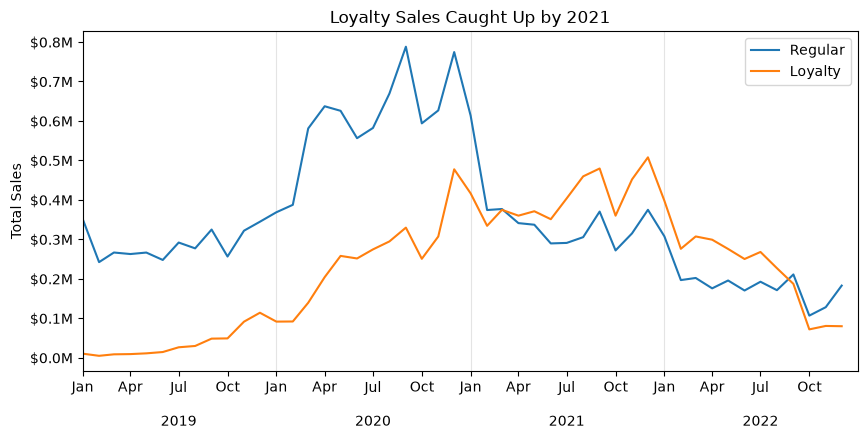

In [73]:
# Monthly total sales by customer type
regular = loyalty_performance[loyalty_performance["CUSTOMER_TYPE"] == "Regular"]
loyalty = loyalty_performance[loyalty_performance["CUSTOMER_TYPE"] == "Loyalty"]

plt.figure(figsize=(10, 5))

ax = plt.gca()
format_monthly_axis(ax)

plt.plot(regular["PURCHASE_DATE"], regular["TOTAL_SALES"], label="Regular")
plt.plot(loyalty["PURCHASE_DATE"], loyalty["TOTAL_SALES"], label="Loyalty")

plt.ylabel("Total Sales")
plt.title("Loyalty Sales Caught Up by 2021")
plt.legend()

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x / 1_000_000:.1f}M")
)

plt.show()

Loyalty sales grew steadily from a very small base and caught up to regular-customer sales by 2021. Loyalty customers generated more monthly sales through much of 2021 and early 2022 before both groups declined later in 2022.

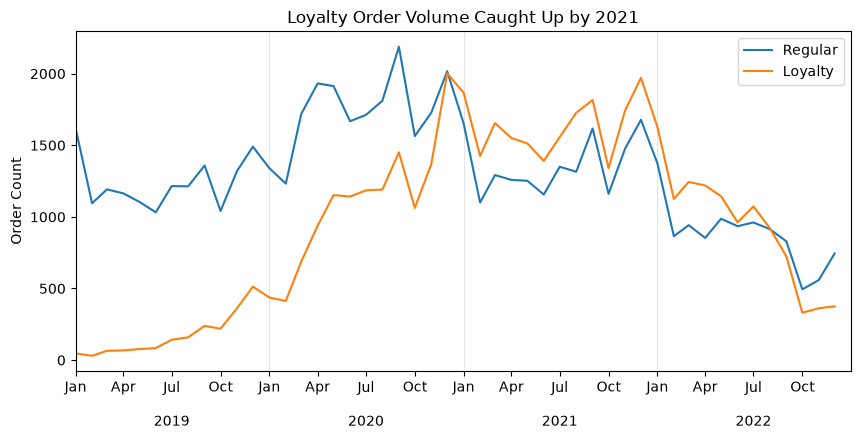

In [74]:
# Monthly order count by customer type
plt.figure(figsize=(10, 5))

ax = plt.gca()
format_monthly_axis(ax)

plt.plot(regular["PURCHASE_DATE"], regular["ORDER_COUNT"], label="Regular")
plt.plot(loyalty["PURCHASE_DATE"], loyalty["ORDER_COUNT"], label="Loyalty")

plt.ylabel("Order Count")
plt.title("Loyalty Order Volume Caught Up by 2021")
plt.legend()

plt.show()

Loyalty order volume rose steadily and caught up to regular customers by 2021. Loyalty customers placed more orders through much of 2021 and early 2022 before both groups declined later in 2022.

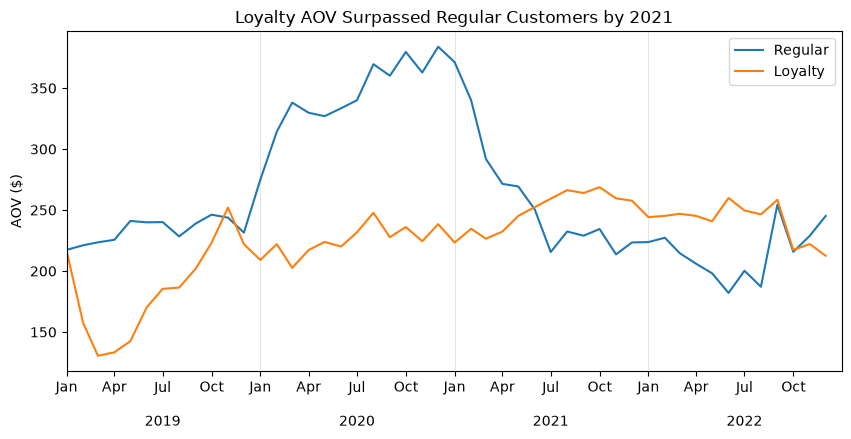

In [75]:
# Monthly AOV by customer type
plt.figure(figsize=(10, 5))

ax = plt.gca()
format_monthly_axis(ax)

plt.plot(regular["PURCHASE_DATE"], regular["AOV"], label="Regular")
plt.plot(loyalty["PURCHASE_DATE"], loyalty["AOV"], label="Loyalty")

plt.ylabel("AOV ($)")
plt.title("Loyalty AOV Surpassed Regular Customers by 2021")
plt.legend()

plt.show()

Loyalty AOV improved steadily while regular-customer AOV declined from its 2020 peak. By mid-2021, loyalty customers were generally spending more per order than regular customers.

##### Loyalty Program Evaluation

**Metric note:** An active customer is a unique customer who placed at least one order during the month. Sales per active customer therefore measures sales among purchasing customers, not all customers enrolled in the loyalty program.

In [76]:
# Standardize customer IDs for customer-level loyalty analysis
loyalty_customer_analysis = orders_clean.copy()
loyalty_customer_analysis["USER_ID"] = loyalty_customer_analysis["USER_ID"].astype(str)

In [77]:
# Monthly customer-level loyalty metrics
loyalty_customer_metrics = loyalty_customer_analysis.groupby(
    ["PURCHASE_YEAR", "PURCHASE_MONTH", "LOYALTY_PROGRAM"],
    as_index=False
).agg({
    "USER_ID": "nunique",
    "ORDER_ID": "count",
    "USD_PRICE": "sum"
})

loyalty_customer_metrics.columns = [
    "PURCHASE_YEAR",
    "PURCHASE_MONTH",
    "LOYALTY_PROGRAM",
    "CUSTOMER_COUNT",
    "ORDER_COUNT",
    "TOTAL_SALES"
]

loyalty_customer_metrics["ORDERS_PER_CUSTOMER"] = (
    loyalty_customer_metrics["ORDER_COUNT"] /
    loyalty_customer_metrics["CUSTOMER_COUNT"]
)

loyalty_customer_metrics["SALES_PER_CUSTOMER"] = (
    loyalty_customer_metrics["TOTAL_SALES"] /
    loyalty_customer_metrics["CUSTOMER_COUNT"]
)

loyalty_customer_metrics.groupby(
    ["PURCHASE_YEAR", "LOYALTY_PROGRAM"]
)[[
    "CUSTOMER_COUNT",
    "ORDERS_PER_CUSTOMER",
    "SALES_PER_CUSTOMER"
]].mean()

CUSTOMER_COUNT  ORDERS_PER_CUSTOMER  \
PURCHASE_YEAR LOYALTY_PROGRAM                                        
2019          0                   1048.833333             1.187943   
              1                    133.666667             1.178997   
2020          0                   1473.833333             1.198136   
              1                    918.166667             1.171360   
2021          0                   1153.166667             1.183966   
              1                   1398.416667             1.175654   
2022          0                    749.083333             1.195467   
              1                    825.916667             1.167584   

                               SALES_PER_CUSTOMER  
PURCHASE_YEAR LOYALTY_PROGRAM                      
2019          0                        276.887039  
              1                        223.404228  
2020          0                        412.353801  
              1                        264.318967  
2021          0                        307.783973  
              1                        293.915826  
2022          0                        260.151431  
              1                        280.549366

In [94]:
# Monthly active customers by loyalty status
loyalty_customer_metrics["PURCHASE_DATE"] = pd.to_datetime({
    "year": loyalty_customer_metrics["PURCHASE_YEAR"],
    "month": loyalty_customer_metrics["PURCHASE_MONTH"],
    "day": 1
})

loyalty_customer_metrics["CUSTOMER_TYPE"] = loyalty_customer_metrics["LOYALTY_PROGRAM"].replace({
    0: "Regular",
    1: "Loyalty"
})

regular_customers = loyalty_customer_metrics[
    loyalty_customer_metrics["CUSTOMER_TYPE"] == "Regular"
]

loyalty_customers = loyalty_customer_metrics[
    loyalty_customer_metrics["CUSTOMER_TYPE"] == "Loyalty"
]

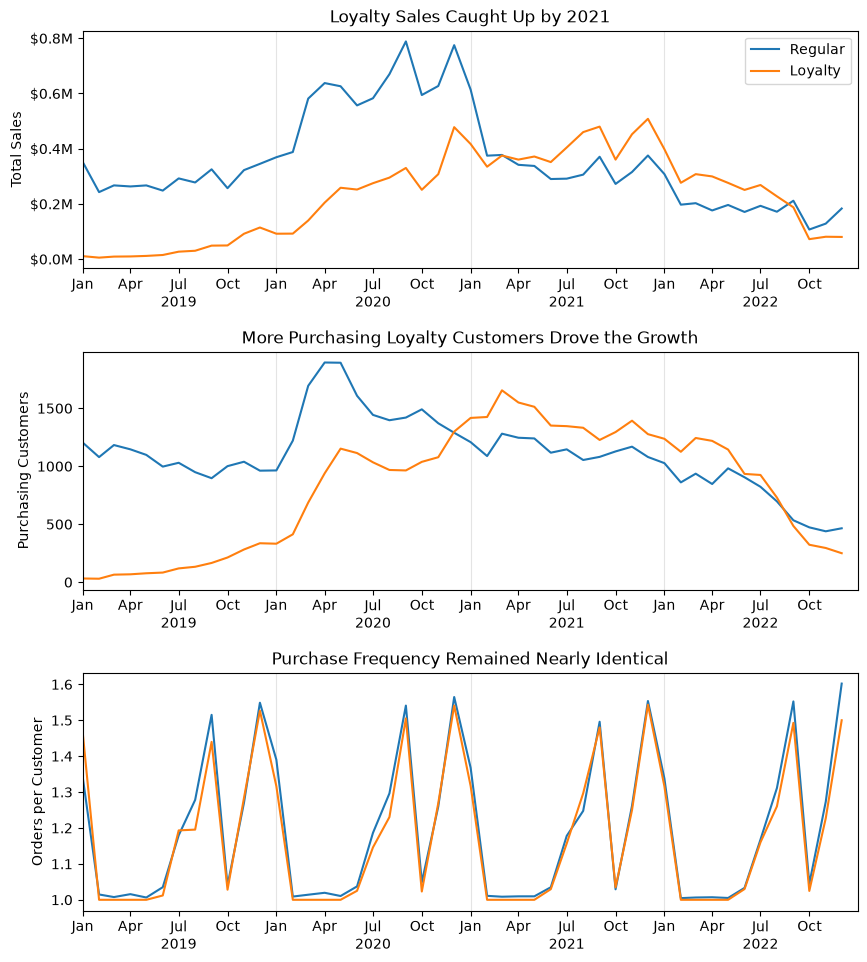

In [113]:
# Loyalty program story
fig, axes = plt.subplots(3, 1, figsize=(10, 11))

# Total sales
axes[0].plot(regular["PURCHASE_DATE"], regular["TOTAL_SALES"], label="Regular")
axes[0].plot(loyalty["PURCHASE_DATE"], loyalty["TOTAL_SALES"], label="Loyalty")
axes[0].set_ylabel("Total Sales")
axes[0].set_title("Loyalty Sales Caught Up by 2021")
axes[0].legend()

axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x / 1_000_000:.1f}M")
)

# Purchasing customers
axes[1].plot(
    regular_customers["PURCHASE_DATE"],
    regular_customers["CUSTOMER_COUNT"]
)
axes[1].plot(
    loyalty_customers["PURCHASE_DATE"],
    loyalty_customers["CUSTOMER_COUNT"]
)
axes[1].set_ylabel("Purchasing Customers")
axes[1].set_title("More Purchasing Loyalty Customers Drove the Growth")

# Orders per purchasing customer
axes[2].plot(
    regular_customers["PURCHASE_DATE"],
    regular_customers["ORDERS_PER_CUSTOMER"]
)
axes[2].plot(
    loyalty_customers["PURCHASE_DATE"],
    loyalty_customers["ORDERS_PER_CUSTOMER"]
)
axes[2].set_ylabel("Orders per Customer")
axes[2].set_title("Purchase Frequency Remained Nearly Identical")

# Date formatting for each chart
for ax in axes:
    format_monthly_axis(ax)

plt.subplots_adjust(hspace=0.35, bottom=0.08)

plt.savefig("images/loyalty_story.png", dpi=150, bbox_inches="tight")
plt.show()

At first glance, the loyalty program appears to be performing strongly: loyalty sales grew from a small base and eventually caught up to or exceeded regular-customer sales.

However, the increase was driven primarily by growth in the number of loyalty customers making purchases. Purchase frequency remained nearly identical between the two groups, at roughly 1.2 orders per purchasing customer per month.

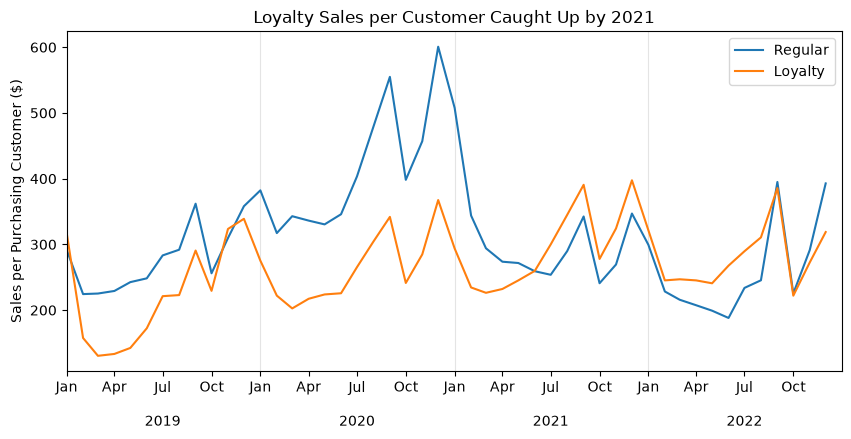

In [98]:
# Monthly sales per active customer by loyalty status
plt.figure(figsize=(10, 5))

ax = plt.gca()
format_monthly_axis(ax)

plt.plot(
    regular_customers["PURCHASE_DATE"],
    regular_customers["SALES_PER_CUSTOMER"],
    label="Regular"
)

plt.plot(
    loyalty_customers["PURCHASE_DATE"],
    loyalty_customers["SALES_PER_CUSTOMER"],
    label="Loyalty"
)

plt.ylabel("Sales per Purchasing Customer ($)")
plt.title("Loyalty Sales per Customer Caught Up by 2021")
plt.legend()

plt.show()

Sales per purchasing loyalty customer initially trailed regular customers but caught up by 2021. Since purchase frequency remained nearly unchanged between the groups, this improvement came primarily from higher spending per order rather than more frequent purchases.

The loyalty segment therefore generated more total sales, but the available data does not show that membership itself caused customers to purchase more frequently. Elist should continue the program for now while tracking retention, incremental spending, and program costs to determine whether loyalty membership is actually changing customer behavior.

### 4.4 Apple Product Refunds and AOV

**Question:** What were the refund rates and average order value?

**Stakeholder clarification:** Focus on differences across Apple products and include refund count in addition to refund rate and AOV. Compare performance by year.

In [80]:
# Apple product orders
apple_products = [
    "Apple Airpods Headphones",
    "Apple iPhone",
    "Macbook Air Laptop"
]

apple_orders = orders_clean[
    orders_clean["PRODUCT_NAME_CLEANED"].isin(apple_products)
].copy()

# Refund flag
apple_orders["IS_REFUND"] = apple_orders["REFUND_TS"].notna().astype(int)

In [81]:
# Apple refund performance
apple_refund_performance = apple_orders.groupby(
    ["PRODUCT_NAME_CLEANED", "PURCHASE_YEAR"],
    as_index=False
).agg({
    "IS_REFUND": ["mean", "sum"],
    "USD_PRICE": "mean",
    "ORDER_ID": "count"
})

apple_refund_performance.columns = [
    "PRODUCT_NAME",
    "PURCHASE_YEAR",
    "REFUND_RATE",
    "REFUND_COUNT",
    "AOV",
    "ORDER_COUNT"
]

apple_refund_performance["PRODUCT"] = apple_refund_performance["PRODUCT_NAME"].replace({
    "Apple Airpods Headphones": "AirPods",
    "Apple iPhone": "iPhone",
    "Macbook Air Laptop": "MacBook Air"
})

apple_refund_performance

,PRODUCT_NAME,PURCHASE_YEAR,REFUND_RATE,REFUND_COUNT,AOV,ORDER_COUNT,PRODUCT
0,Apple Airpods Headphones,2019,0.057944,473,157.432250,8163,AirPods
1,Apple Airpods Headphones,2020,0.095574,1529,159.470136,15998,AirPods
2,Apple Airpods Headphones,2021,0.041560,634,162.781755,15255,AirPods
3,Apple Airpods Headphones,2022,0.000000,0,157.992775,8986,AirPods
4,Apple iPhone,2019,0.108696,5,741.302826,46,iPhone
5,Apple iPhone,2020,0.105691,13,748.857236,123,iPhone
6,Apple iPhone,2021,0.052632,4,744.409737,76,iPhone
7,Apple iPhone,2022,0.000000,0,710.304186,43,iPhone
8,Macbook Air Laptop,2019,0.183060,67,1657.789126,366,MacBook Air
9,Macbook Air Laptop,2020,0.168564,311,1591.593149,1845,MacBook Air


In [82]:
# Refund processing time
refund_lag = apple_orders[apple_orders["IS_REFUND"] == 1].copy()

refund_lag["DAYS_TO_REFUND"] = (
    refund_lag["REFUND_TS"] - refund_lag["PURCHASE_TS_CLEANED"]
).dt.days

refund_lag["DAYS_TO_REFUND"].describe()

count    3111.000000
mean      740.372549
std        36.579892
min       681.000000
25%       713.000000
50%       739.000000
75%       765.500000
max      1515.000000
Name: DAYS_TO_REFUND, dtype: float64

In [83]:
refund_lag.groupby("PURCHASE_YEAR")["DAYS_TO_REFUND"].agg([
    "count",
    "median",
    "mean",
    "min",
    "max"
])

,count,median,mean,min,max
PURCHASE_YEAR,,,,,
2019,545,742.0,744.322936,683,1515
2020,1853,741.0,741.934700,681,965
2021,713,733.0,733.293128,681,808


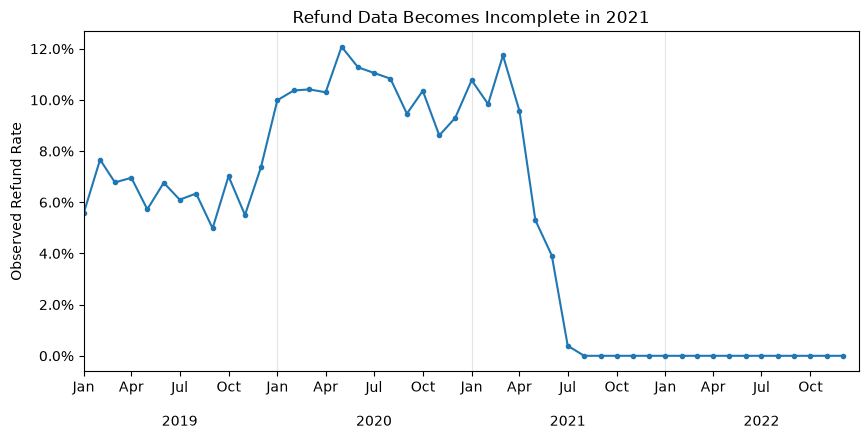

In [102]:
# Monthly Apple refund rate by purchase date
apple_refund_monthly = apple_orders.groupby(
    ["PURCHASE_YEAR", "PURCHASE_MONTH"],
    as_index=False
).agg({
    "IS_REFUND": "mean",
    "ORDER_ID": "count"
})

apple_refund_monthly = apple_refund_monthly.rename(columns={
    "ORDER_ID": "ORDER_COUNT"
})

apple_refund_monthly["PURCHASE_DATE"] = pd.to_datetime({
    "year": apple_refund_monthly["PURCHASE_YEAR"],
    "month": apple_refund_monthly["PURCHASE_MONTH"],
    "day": 1
})

plt.figure(figsize=(10, 5))

ax = plt.gca()
format_monthly_axis(ax)

plt.plot(
    apple_refund_monthly["PURCHASE_DATE"],
    apple_refund_monthly["IS_REFUND"],
    marker="o",
    markersize=3
)

plt.ylabel("Observed Refund Rate")
plt.title("Refund Data Becomes Incomplete in 2021")

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.savefig("images/refund_data_completeness.png", dpi=150, bbox_inches="tight")

plt.show()

**Data note:** Refunds are typically recorded about two years after purchase (median: 739 days). The monthly refund rate drops sharply during 2021 and reaches nearly 0% by the second half of the year, while all 2022 purchase months show 0% observed refunds.

This indicates that recent purchase periods do not have enough time to accumulate refunds. The refund-risk comparison therefore focuses on 2019-2020 orders, while 2021 and 2022 are excluded from the final product comparison.

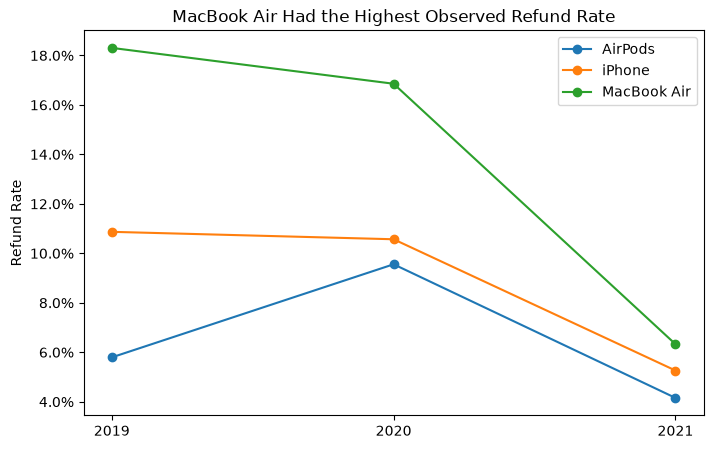

In [84]:
# Refund rate by Apple product
apple_refund_plot = apple_refund_performance[
    apple_refund_performance["PURCHASE_YEAR"] < 2022
].copy()

plt.figure(figsize=(8, 5))

for product in apple_refund_plot["PRODUCT"].unique():
    product_data = apple_refund_plot[apple_refund_plot["PRODUCT"] == product]

    plt.plot(
        product_data["PURCHASE_YEAR"],
        product_data["REFUND_RATE"],
        marker="o",
        label=product
    )

plt.xticks([2019, 2020, 2021])
plt.ylabel("Refund Rate")
plt.title("MacBook Air Had the Highest Observed Refund Rate")
plt.legend()

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.show()

MacBook Air had the highest observed refund rate across the Apple products, followed by iPhone and AirPods. Observed refund rates were lower in later purchase years, although this may partly reflect the refund-processing lag.

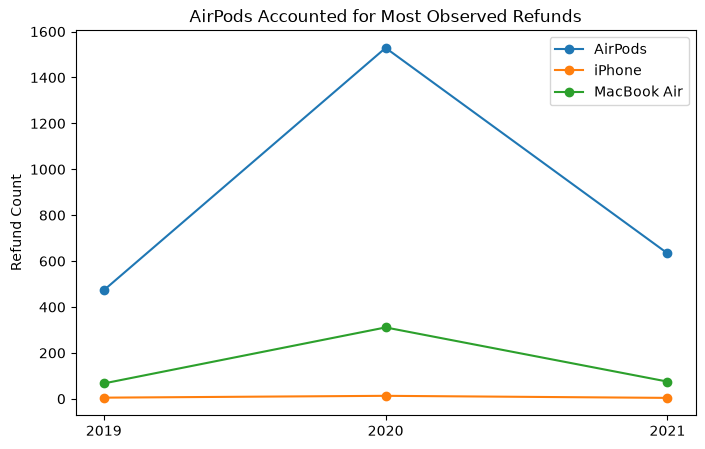

In [85]:
# Refund count by Apple product
plt.figure(figsize=(8, 5))

for product in apple_refund_plot["PRODUCT"].unique():
    product_data = apple_refund_plot[apple_refund_plot["PRODUCT"] == product]

    plt.plot(
        product_data["PURCHASE_YEAR"],
        product_data["REFUND_COUNT"],
        marker="o",
        label=product
    )

plt.xticks([2019, 2020, 2021])
plt.ylabel("Refund Count")
plt.title("AirPods Accounted for Most Observed Refunds")
plt.legend()

plt.show()

AirPods generated far more observed refunds than the other Apple products because of their much higher order volume. MacBook Air had the highest refund rate, showing why refund count and refund rate need to be considered together.

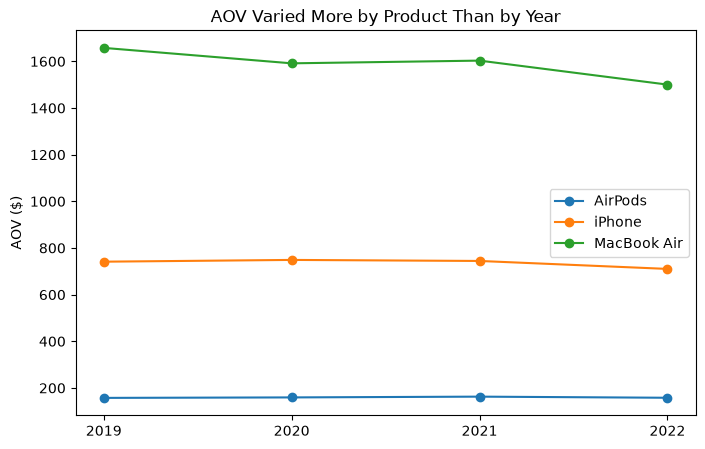

In [86]:
# AOV by Apple product
plt.figure(figsize=(8, 5))

for product in apple_refund_performance["PRODUCT"].unique():
    product_data = apple_refund_performance[
        apple_refund_performance["PRODUCT"] == product
    ]

    plt.plot(
        product_data["PURCHASE_YEAR"],
        product_data["AOV"],
        marker="o",
        label=product
    )

plt.xticks([2019, 2020, 2021, 2022])
plt.ylabel("AOV ($)")
plt.title("AOV Varied More by Product Than by Year")
plt.legend()

plt.show()

AOV remained relatively stable within each Apple product. MacBook Air averaged roughly $1.5K–$1.7K per order, iPhone about $700–$750, and AirPods about $160.

##### Refund Risk Evaluation

In [87]:
# Refund processing time by Apple product
refund_lag.groupby("PRODUCT_NAME_CLEANED")["DAYS_TO_REFUND"].agg([
    "count",
    "median",
    "mean",
    "min",
    "max"
])

,count,median,mean,min,max
PRODUCT_NAME_CLEANED,,,,,
Apple Airpods Headphones,2636,736.0,737.909332,681,1515
Apple iPhone,22,738.5,738.863636,698,782
Macbook Air Laptop,453,755.0,754.779249,684,970


In [88]:
# Refund rates for more mature purchase cohorts
mature_refunds = apple_orders[
    apple_orders["PURCHASE_YEAR"].isin([2019, 2020])
].groupby(
    "PRODUCT_NAME_CLEANED",
    as_index=False
).agg({
    "IS_REFUND": ["mean", "sum"],
    "ORDER_ID": "count"
})

mature_refunds.columns = [
    "PRODUCT_NAME",
    "REFUND_RATE",
    "REFUND_COUNT",
    "ORDER_COUNT"
]

mature_refunds

,PRODUCT_NAME,REFUND_RATE,REFUND_COUNT,ORDER_COUNT
0,Apple Airpods Headphones,0.082861,2002,24161
1,Apple iPhone,0.106509,18,169
2,Macbook Air Laptop,0.170963,378,2211


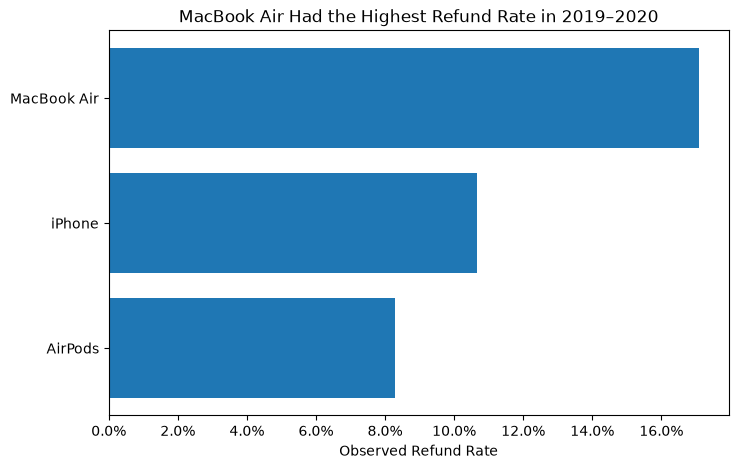

In [89]:
# Refund rates for mature 2019–2020 cohorts
mature_refund_plot = mature_refunds.copy()

mature_refund_plot["PRODUCT"] = mature_refund_plot["PRODUCT_NAME"].replace({
    "Apple Airpods Headphones": "AirPods",
    "Apple iPhone": "iPhone",
    "Macbook Air Laptop": "MacBook Air"
})

mature_refund_plot = mature_refund_plot.sort_values("REFUND_RATE")

plt.figure(figsize=(8, 5))
plt.barh(mature_refund_plot["PRODUCT"], mature_refund_plot["REFUND_RATE"])

plt.xlabel("Observed Refund Rate")
plt.title("MacBook Air Had the Highest Refund Rate in 2019–2020")

plt.gca().xaxis.set_major_formatter(PercentFormatter(1))

plt.savefig("images/apple_refund_rates.png", dpi=150, bbox_inches="tight")
plt.show()

In [90]:
# Refunded sales by Apple product for mature cohorts
mature_refund_sales = apple_orders[
    (apple_orders["PURCHASE_YEAR"].isin([2019, 2020])) &
    (apple_orders["IS_REFUND"] == 1)
].groupby(
    "PRODUCT_NAME_CLEANED",
    as_index=False
).agg({
    "USD_PRICE": "sum"
})

mature_refund_sales = mature_refund_sales.rename(columns={
    "USD_PRICE": "REFUNDED_SALES"
})

In [91]:
# Refunded sales as a share of total sales for mature cohorts
mature_sales = apple_orders[
    apple_orders["PURCHASE_YEAR"].isin([2019, 2020])
].groupby(
    "PRODUCT_NAME_CLEANED",
    as_index=False
).agg({
    "USD_PRICE": "sum"
})

mature_sales = mature_sales.rename(columns={
    "USD_PRICE": "TOTAL_SALES"
})

mature_refund_impact = mature_sales.merge(
    mature_refund_sales,
    on="PRODUCT_NAME_CLEANED",
    how="left"
)

mature_refund_impact["REFUNDED_SALES_RATE"] = (
    mature_refund_impact["REFUNDED_SALES"] /
    mature_refund_impact["TOTAL_SALES"]
)

mature_refund_impact

,PRODUCT_NAME_CLEANED,TOTAL_SALES,REFUNDED_SALES,REFUNDED_SALES_RATE
0,Apple Airpods Headphones,3836322.70,323567.30,0.084343
1,Apple iPhone,126209.37,12948.59,0.102596
2,Macbook Air Laptop,3543240.18,617971.31,0.174409


In [92]:
# MacBook refund rate by region for mature cohorts
macbook_refunds_region = apple_orders[
    (apple_orders["PRODUCT_NAME_CLEANED"] == "Macbook Air Laptop") &
    (apple_orders["PURCHASE_YEAR"].isin([2019, 2020]))
].groupby(
    "REGION",
    as_index=False
).agg({
    "IS_REFUND": ["mean", "sum"],
    "ORDER_ID": "count"
})

macbook_refunds_region.columns = [
    "REGION",
    "REFUND_RATE",
    "REFUND_COUNT",
    "ORDER_COUNT"
]

macbook_refunds_region.sort_values("REFUND_RATE", ascending=False)

,REGION,REFUND_RATE,REFUND_COUNT,ORDER_COUNT
0,APAC,0.219512,72,328
3,NA,0.177237,204,1151
2,LATAM,0.164634,27,164
1,EMEA,0.132042,75,568


Using the more mature 2019–2020 purchase cohorts reduces the impact of the roughly two-year refund lag. MacBook Air still had the highest observed refund rate at about 17%, compared with 11% for iPhone and 8% for AirPods.

MacBook Air also represented the largest financial exposure: about $618K in sales were associated with refunded orders, equal to roughly 17% of MacBook sales in the mature cohorts. Its elevated refund rate appeared across all regions, although APAC was highest at about 22%, suggesting a broad product-level concern rather than an issue isolated to one market.

Because the dataset contains a refund timestamp but not the actual refund amount, sales associated with refunded orders should be treated as potential exposure rather than confirmed refunded revenue.

Overall, MacBook Air was the primary Apple refund-risk concern. It had the highest observed refund rate, remained highest at about 17% when the analysis was limited to mature 2019–2020 cohorts, and had about $618K in sales associated with refunded orders. AirPods generated the most refunds by count because of their much higher order volume, while AOV differences were driven primarily by product type. Recent refund metrics should still be interpreted cautiously because of the roughly two-year reporting lag.

## 5. Conclusions and Recommendations

Elist experienced rapid growth through 2020 before entering a broad decline that became especially severe in late 2022. The strongest opportunities are to understand and recover lost order volume, improve measurement of the loyalty program, and address elevated MacBook Air refund risk.

### Key Findings

- **Sales peaked in 2020 before declining through 2022.** Annual sales increased about 163% in 2020 as both order volume (+101%) and AOV (+31%) rose. The AOV increase was driven primarily by a shift toward higher-value products rather than broad price increases.

- **The 2022 decline was primarily an order-volume problem.** Sales fell about 46% and orders fell about 40%, while AOV declined only about 10%. The slowdown became especially severe late in the year, with September–December order volume roughly 55%–71% below the same months in 2021.

- **Elist showed a recurring seasonal pattern driven by order volume.** December and September performed about 23% and 16% above trend, while February and October were among the weakest months. The pattern appeared across most major products rather than being driven by a single category.

- **The loyalty segment grew substantially, but higher purchasing frequency was not the driver.** Growth in active loyalty customers pushed loyalty sales toward and eventually above regular-customer sales, while orders per active customer remained near 1.2 for both groups. Sales per active loyalty customer caught up by 2021, largely through higher spending per order.

- **Sales and orders were highly concentrated.** The top three products generated about 85% of sales and 87% of orders, while North America accounted for more than half of both regional sales and order volume.

- **MacBook Air represented the largest Apple refund risk.** In the more mature 2019–2020 cohorts, MacBook Air had an observed refund rate of about 17%, compared with 11% for iPhone and 8% for AirPods. About $618K in MacBook sales were associated with refunded orders, and elevated refund rates appeared across all regions.

### Recommendations

- **Plan inventory and promotions around the recurring seasonal demand pattern.** September and December consistently outperformed trend, while February and October were weaker. Elist should prepare inventory and marketing for stronger late-year demand while avoiding overstock during historically slower periods.

- **Continue the loyalty program while improving how its impact is measured.** The loyalty segment grew substantially and loyalty customers eventually matched or exceeded regular customers in sales per active customer, but purchase frequency did not increase. Elist should track retention, repeat purchasing, incremental spending, and program costs to determine whether loyalty membership is actually changing customer behavior.

- **Investigate the elevated MacBook Air refund rate as a product-level issue.** MacBook Air had the highest observed refund rate and the largest potential financial exposure across mature Apple cohorts. Elist should review refund reasons, product quality, fulfillment issues, and supplier or product-version differences, with additional attention to APAC where the observed rate was highest.

- **Investigate and reverse the late-2022 order decline, focusing first on Elist's highest-revenue products.** The 2022 slowdown was driven primarily by fewer orders, and the 4K monitor, AirPods, MacBook Air, and ThinkPad accounted for most of the lost sales. Elist should examine customer acquisition and retention, marketing performance, product availability, competitive pricing, and other internal changes that could explain why its decline was steeper than the broader technology market.

### Limitations / Areas for Further Analysis

- **Refund data has a substantial reporting lag.** Refunds were typically recorded about two years after purchase, making 2021 less mature and 2022 unsuitable for reliable refund-rate comparisons. The dataset also does not include actual refund amounts or refund reasons, limiting the ability to measure financial impact or determine why MacBook Air refunds were elevated.

- **The loyalty data does not provide enough information to measure program ROI.** Program costs, discounts, rewards, enrollment details, and retention are not available. The analysis can compare loyalty and regular customers, but it cannot determine whether the program itself caused changes in customer behavior.

- **Seasonality should be treated as directional.** The dataset covers only four years, including the unusual pandemic period, so recurring monthly patterns such as September and December strength should be validated with additional years of data.

- **External events provide context but do not establish causation.** Pandemic-related changes, consumer technology demand, inflation, holiday shopping, and back-to-school activity align with several Elist trends, but the available data cannot determine how much each factor contributed.

- **Additional internal data would help explain the late-2022 decline.** Marketing performance, customer acquisition and retention, product availability, competitive pricing, and other operational changes are not available in the current dataset and would help determine why Elist's slowdown was substantially steeper than the broader technology market.

- **A small number of data-quality issues remain.** Three orders had unknown purchase dates and 33 orders had missing USD prices. These records were retained where possible but excluded from analyses that required the missing fields.

## 6. External Sources

1. U.S. Census Bureau — pandemic-era e-commerce growth
2. National Retail Federation — winter holiday and back-to-school shopping patterns
3. Circana / NPD — 2022 U.S. consumer technology sales decline
4. IDC — late-2022 PC and monitor shipment declines
5. U.S. Bureau of Labor Statistics — 2022 inflation